In [23]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm
from pathlib import Path

Initialize path to the directories 

In [24]:
repo_root = next(
    parent
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)

data_path = (
    repo_root
    / "data"
    / "multi_asset"
    / "quantum"
    / "training"
    / "qcbm"
    / "training_statevector.npz"
)

Load data from the QCBM training in statevector mode

In [25]:
data = np.load(
    data_path,
    allow_pickle=True,
)

p_target = data["p_target"] 
p_star = data['p_star']

print(p_star.shape)
print(p_target.shape)

(1024,)
(1024,)


Build a function for optimal representation of the probability distributions

In [30]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def comparative_plot_distributions(
    p_target,
    p_star,
    *,
    block_size: int = 128,
    log_scale: bool = False,
    alpha_target: float = 0.55,
    alpha_star: float = 0.55,
    figsize: tuple[float, float] = (16, 5.5),
    dpi: int = 180,
    save_dir: str | Path | None = None,
    prefix: str = "distribution_overlay_block",
    show: bool = True,
):
    """
    Representación tipo paper de dos distribuciones discretas largas,
    mostrando solo el overlay bloque a bloque.
    """
    pt = np.asarray(p_target, dtype=float).ravel()
    ps = np.asarray(p_star, dtype=float).ravel()

    if pt.shape != ps.shape:
        raise ValueError("p_target y p_star deben tener la misma longitud.")

    if np.any(pt < 0) or np.any(ps < 0):
        raise ValueError("Las probabilidades no pueden ser negativas.")

    if pt.sum() <= 0 or ps.sum() <= 0:
        raise ValueError("Las distribuciones deben tener suma positiva.")

    pt = pt / pt.sum()
    ps = ps / ps.sum()

    n = pt.size
    n_blocks = math.ceil(n / block_size)
    figs: list[plt.Figure] = []

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

    eps = 1e-16

    for block_idx in range(n_blocks):
        start = block_idx * block_size
        end = min((block_idx + 1) * block_size, n)

        x = np.arange(start, end)
        y_target = pt[start:end].copy()
        y_star = ps[start:end].copy()

        if log_scale:
            y_target = np.maximum(y_target, eps)
            y_star = np.maximum(y_star, eps)

        fig, ax = plt.subplots(
            1,
            1,
            figsize=figsize,
            dpi=dpi,
            constrained_layout=True,
        )

        ax.grid(True, axis="y", alpha=0.25, linewidth=0.7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=10)

        ax.bar(
            x,
            y_target,
            width=0.9,
            alpha=alpha_target,
            edgecolor="black",
            linewidth=0.2,
            label=r"$p_{\mathrm{target}}$",
        )
        ax.bar(
            x,
            y_star,
            width=0.9,
            alpha=alpha_star,
            edgecolor="black",
            linewidth=0.2,
            label=r"$p_{\star}$",
        )

        if log_scale:
            ax.set_yscale("log")

        ax.set_xlabel("State index", fontsize=11)
        ax.set_ylabel("Probability", fontsize=11)
        ax.set_title(
            rf"Overlay: $p_{{\mathrm{{target}}}}$ vs $p_{{\star}}$ — states {start} to {end - 1}",
            fontsize=13,
            pad=10,
        )
        ax.legend(frameon=False, fontsize=10, loc="upper right")

        figs.append(fig)

        if save_dir is not None:
            out = save_dir / f"{prefix}_{block_idx + 1:02d}.png"
            fig.savefig(out, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)

    return figs

And plot the differences

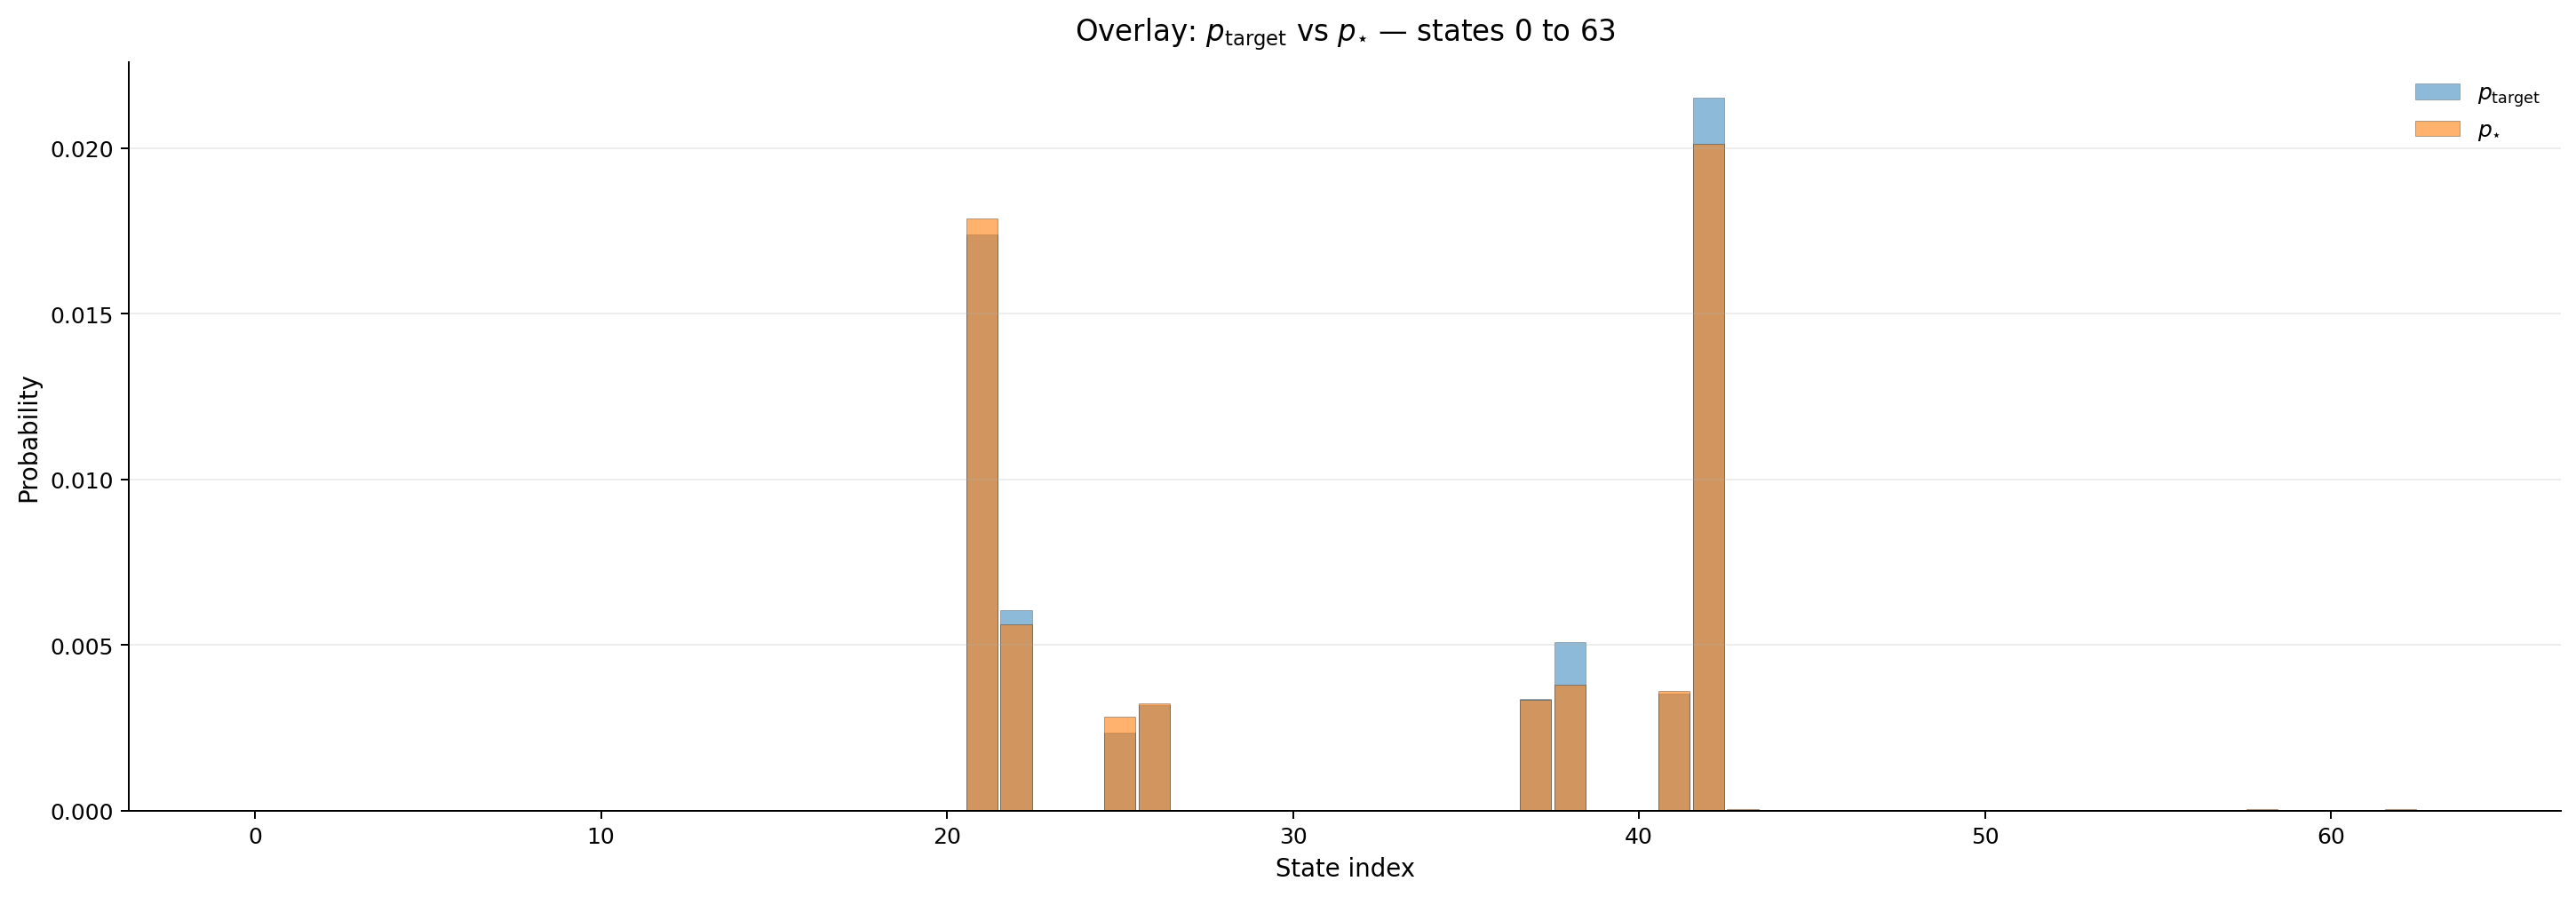

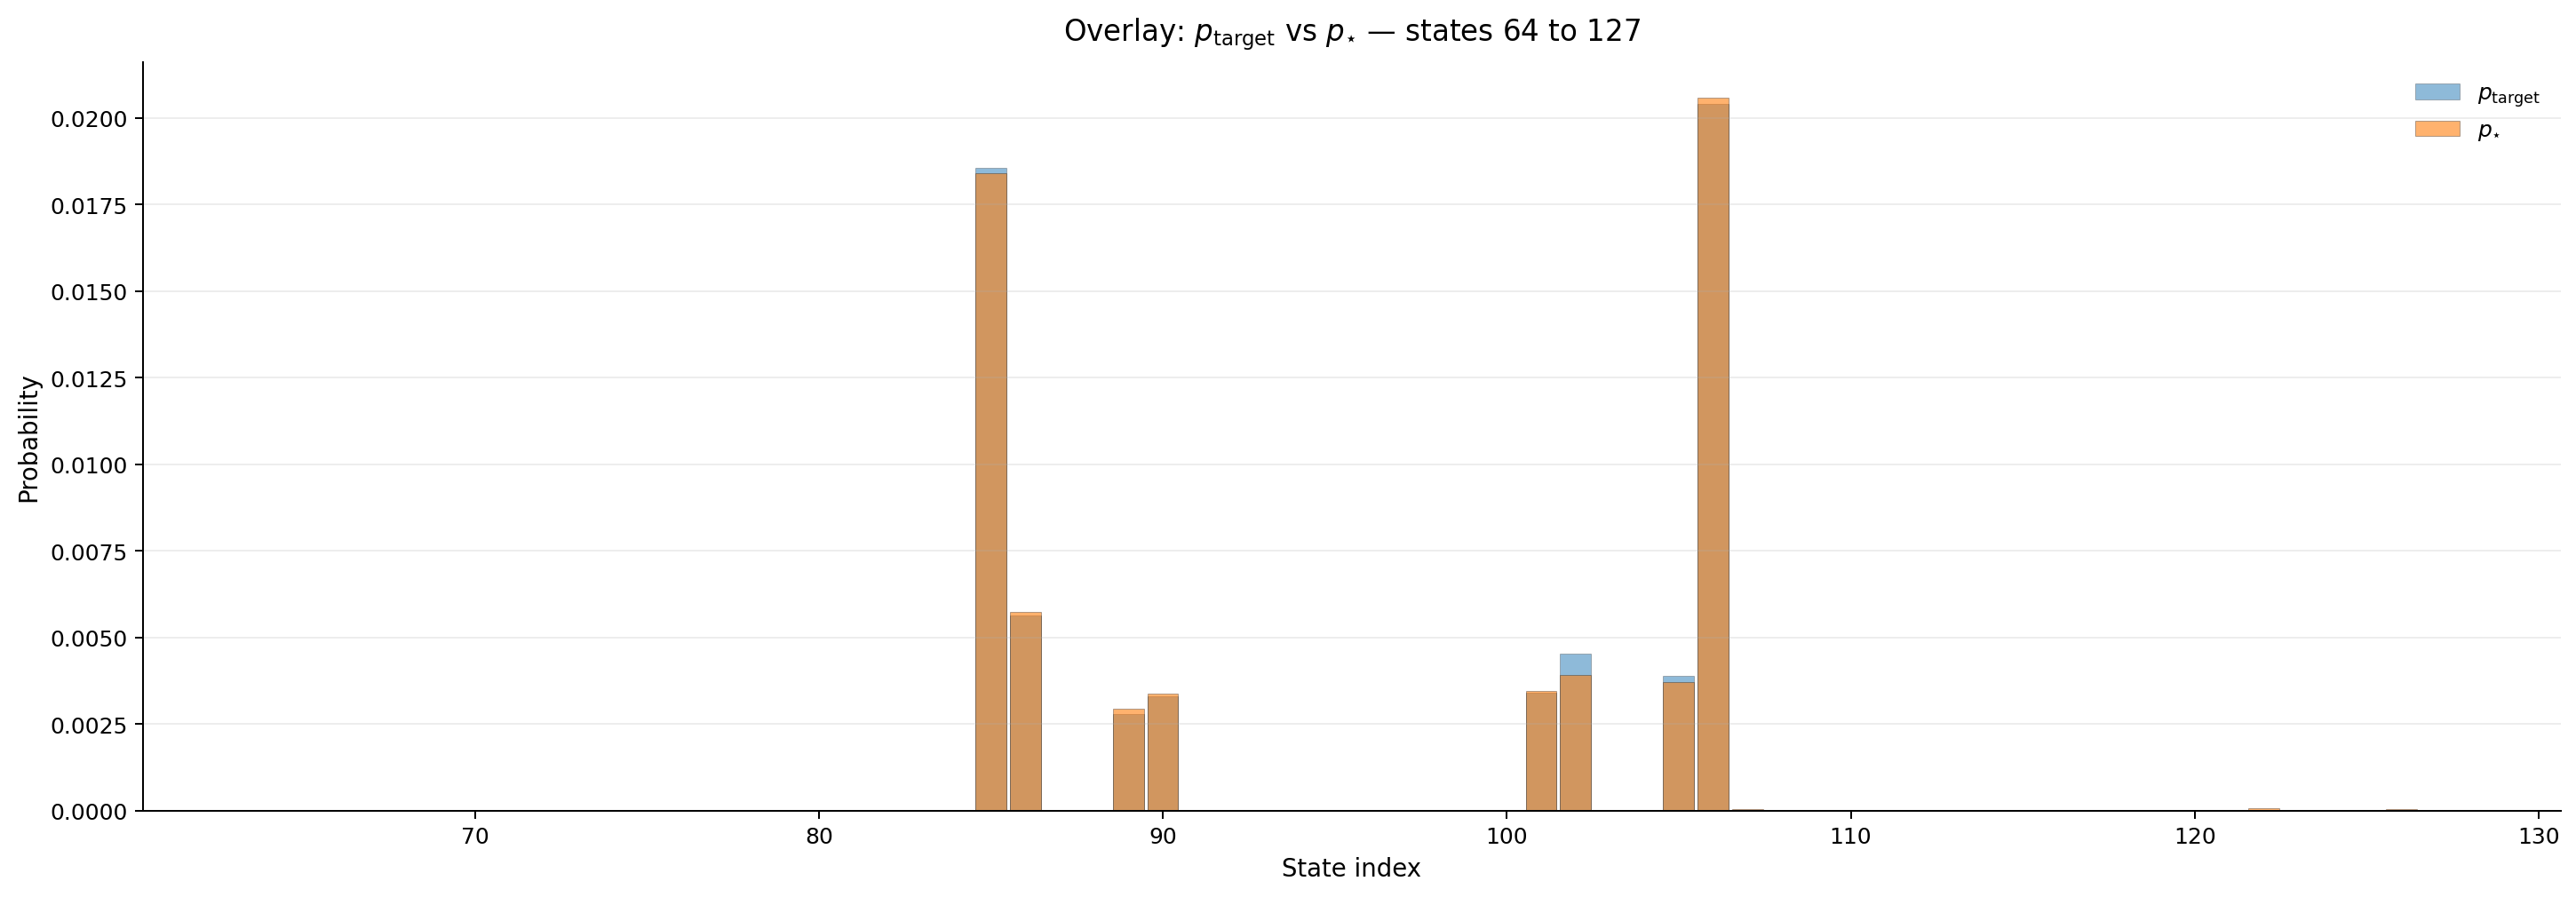

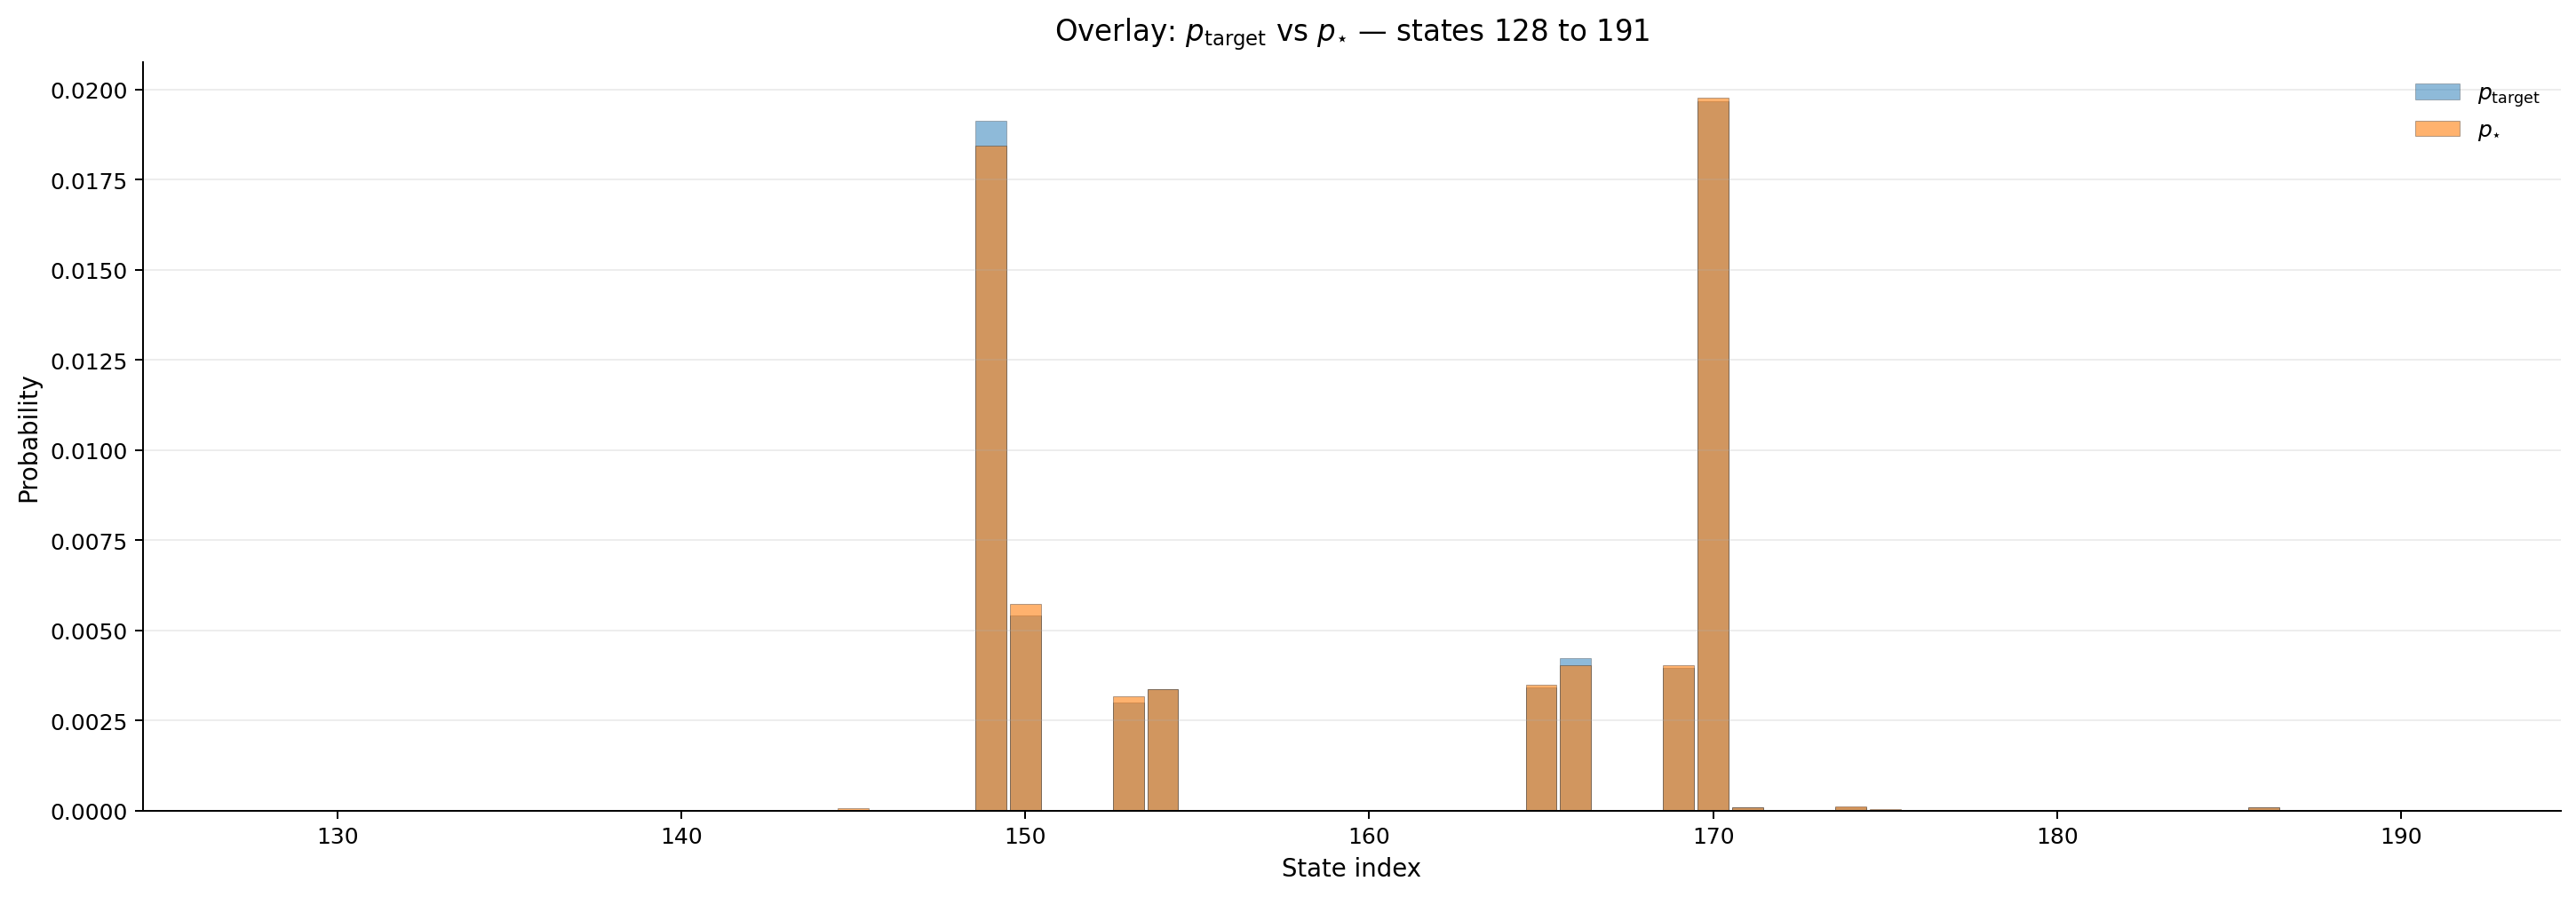

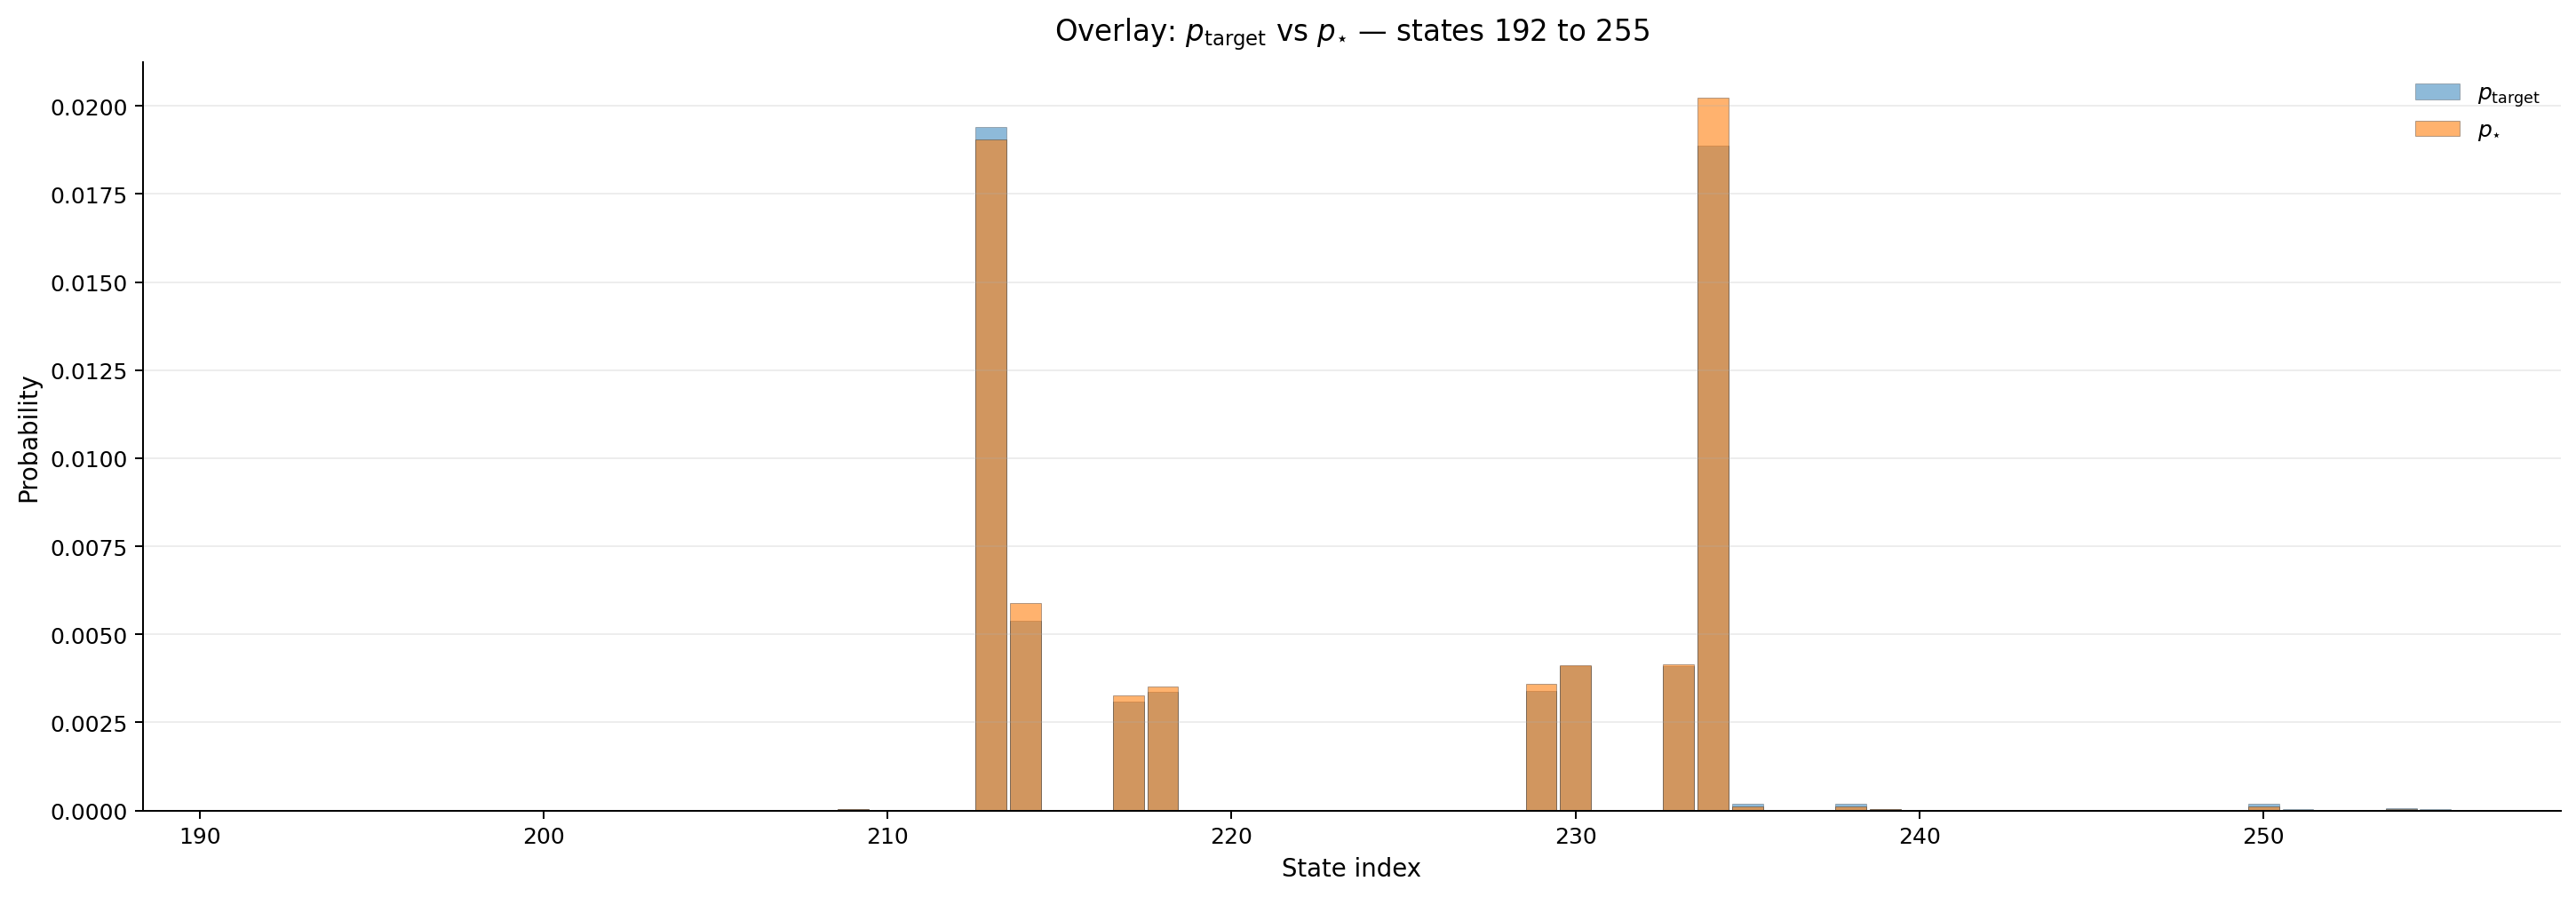

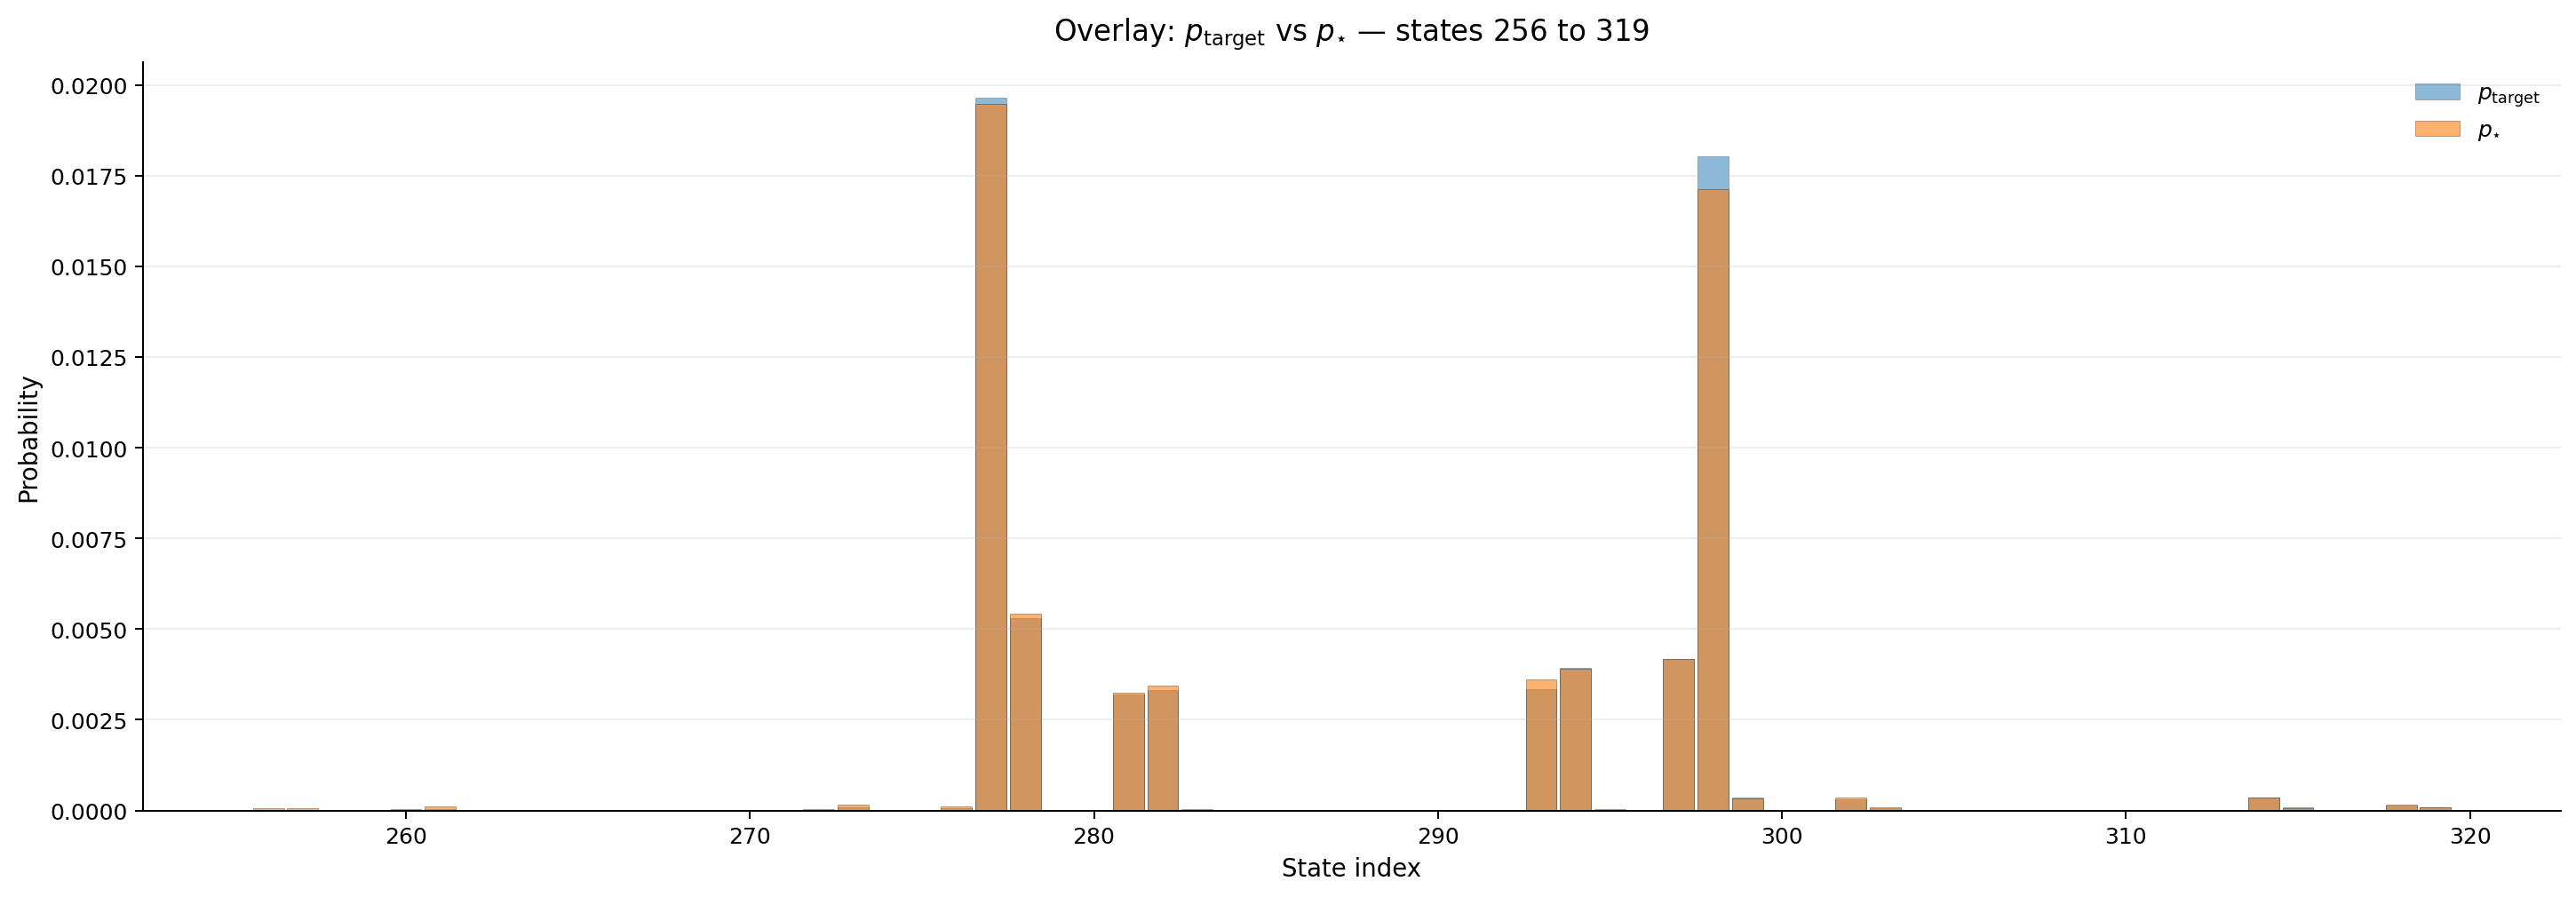

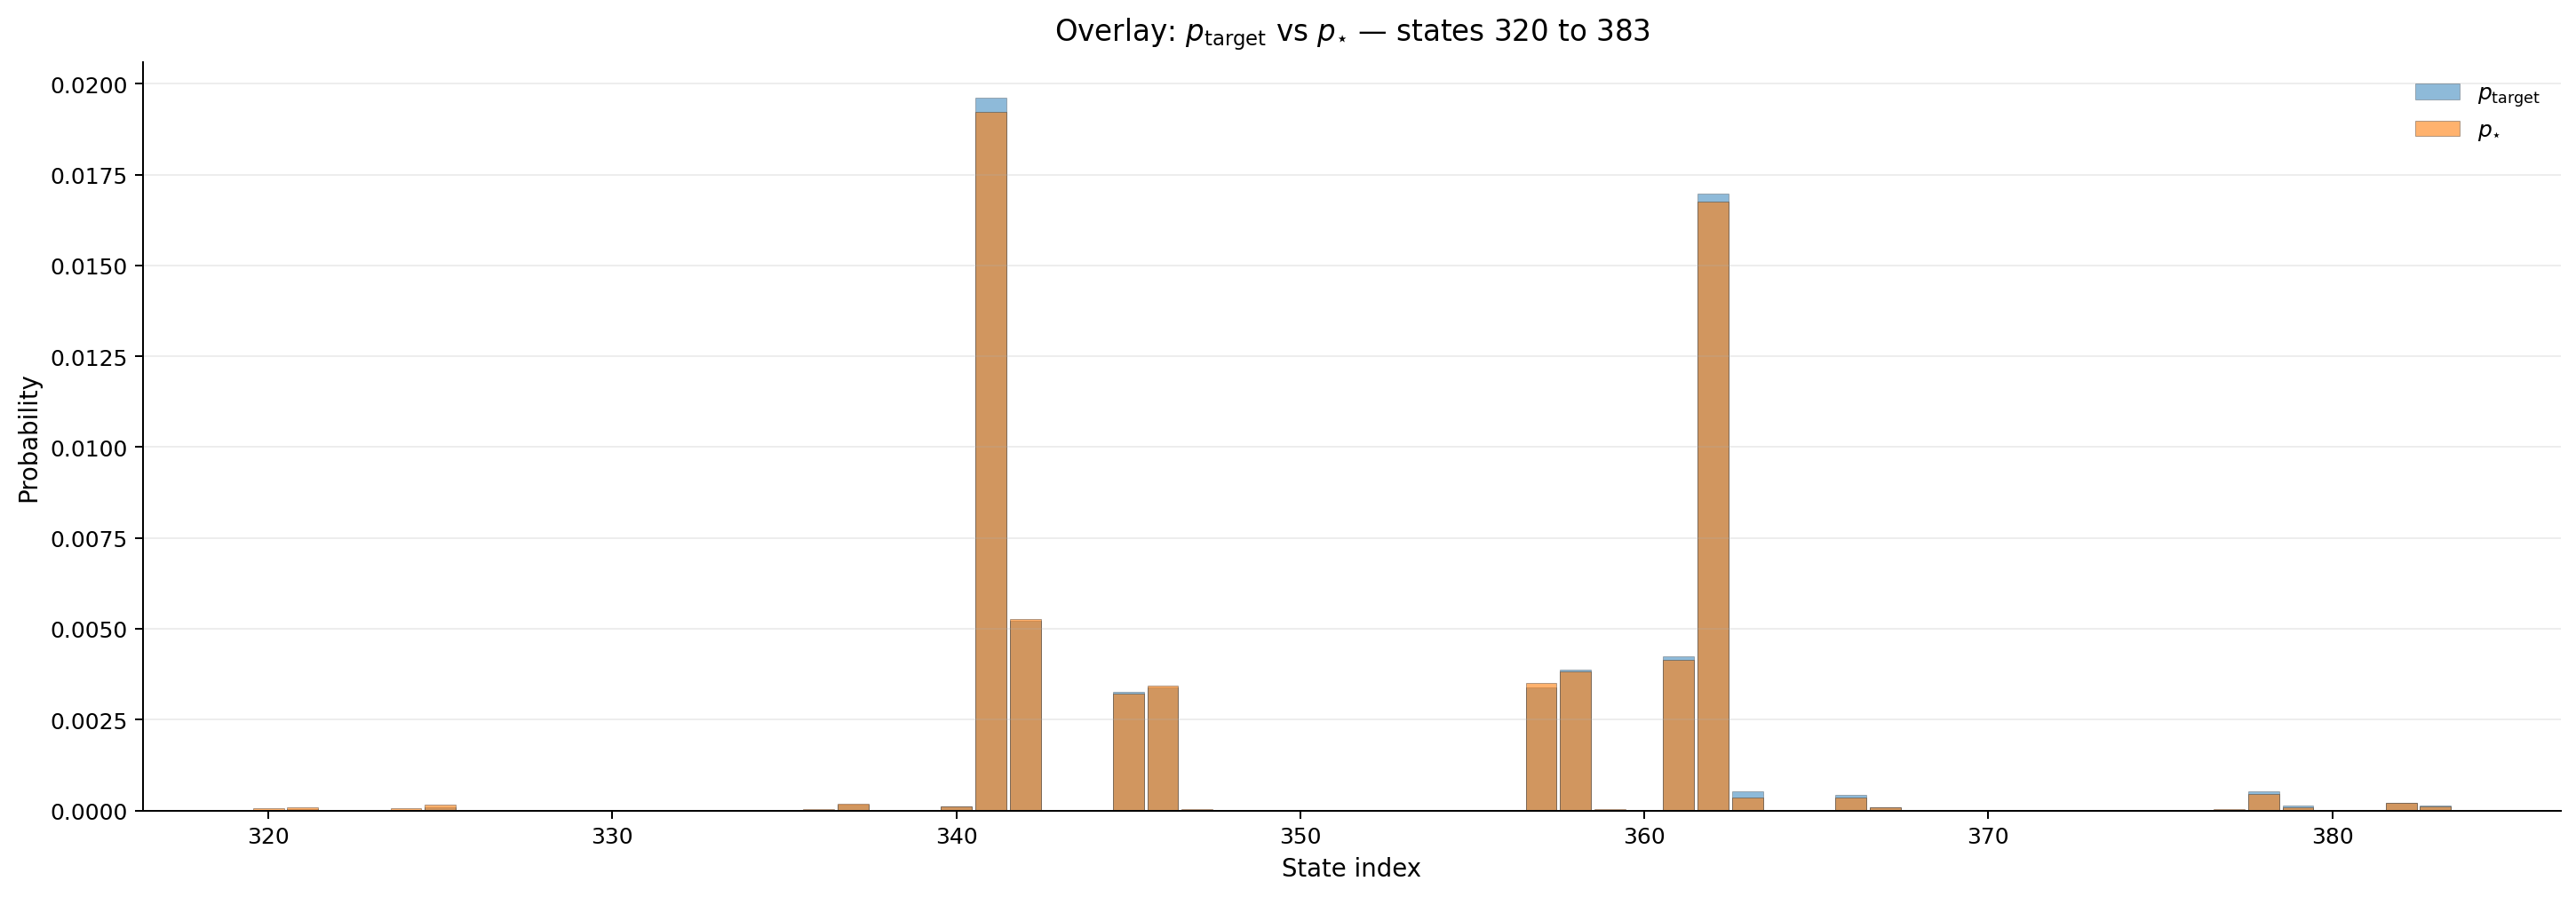

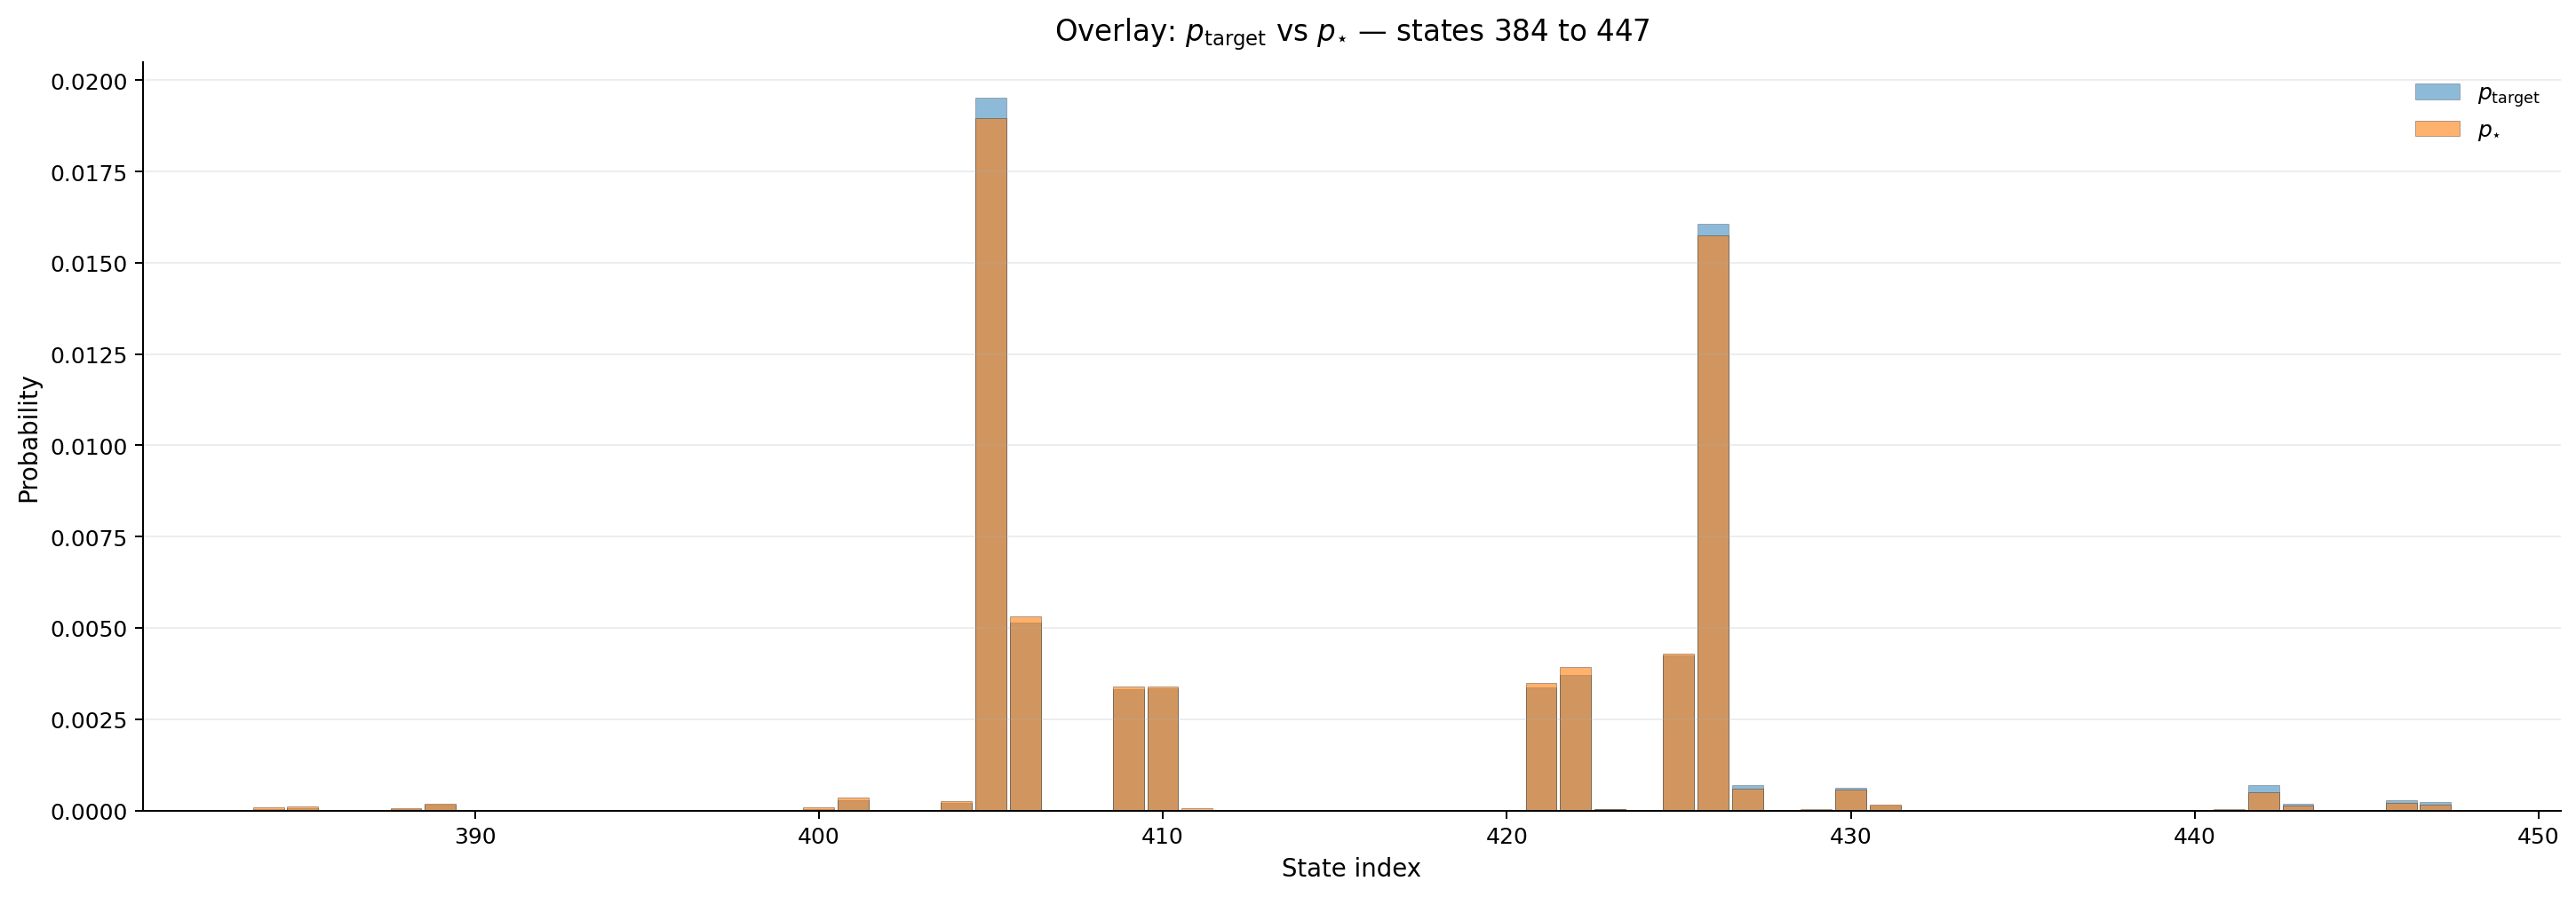

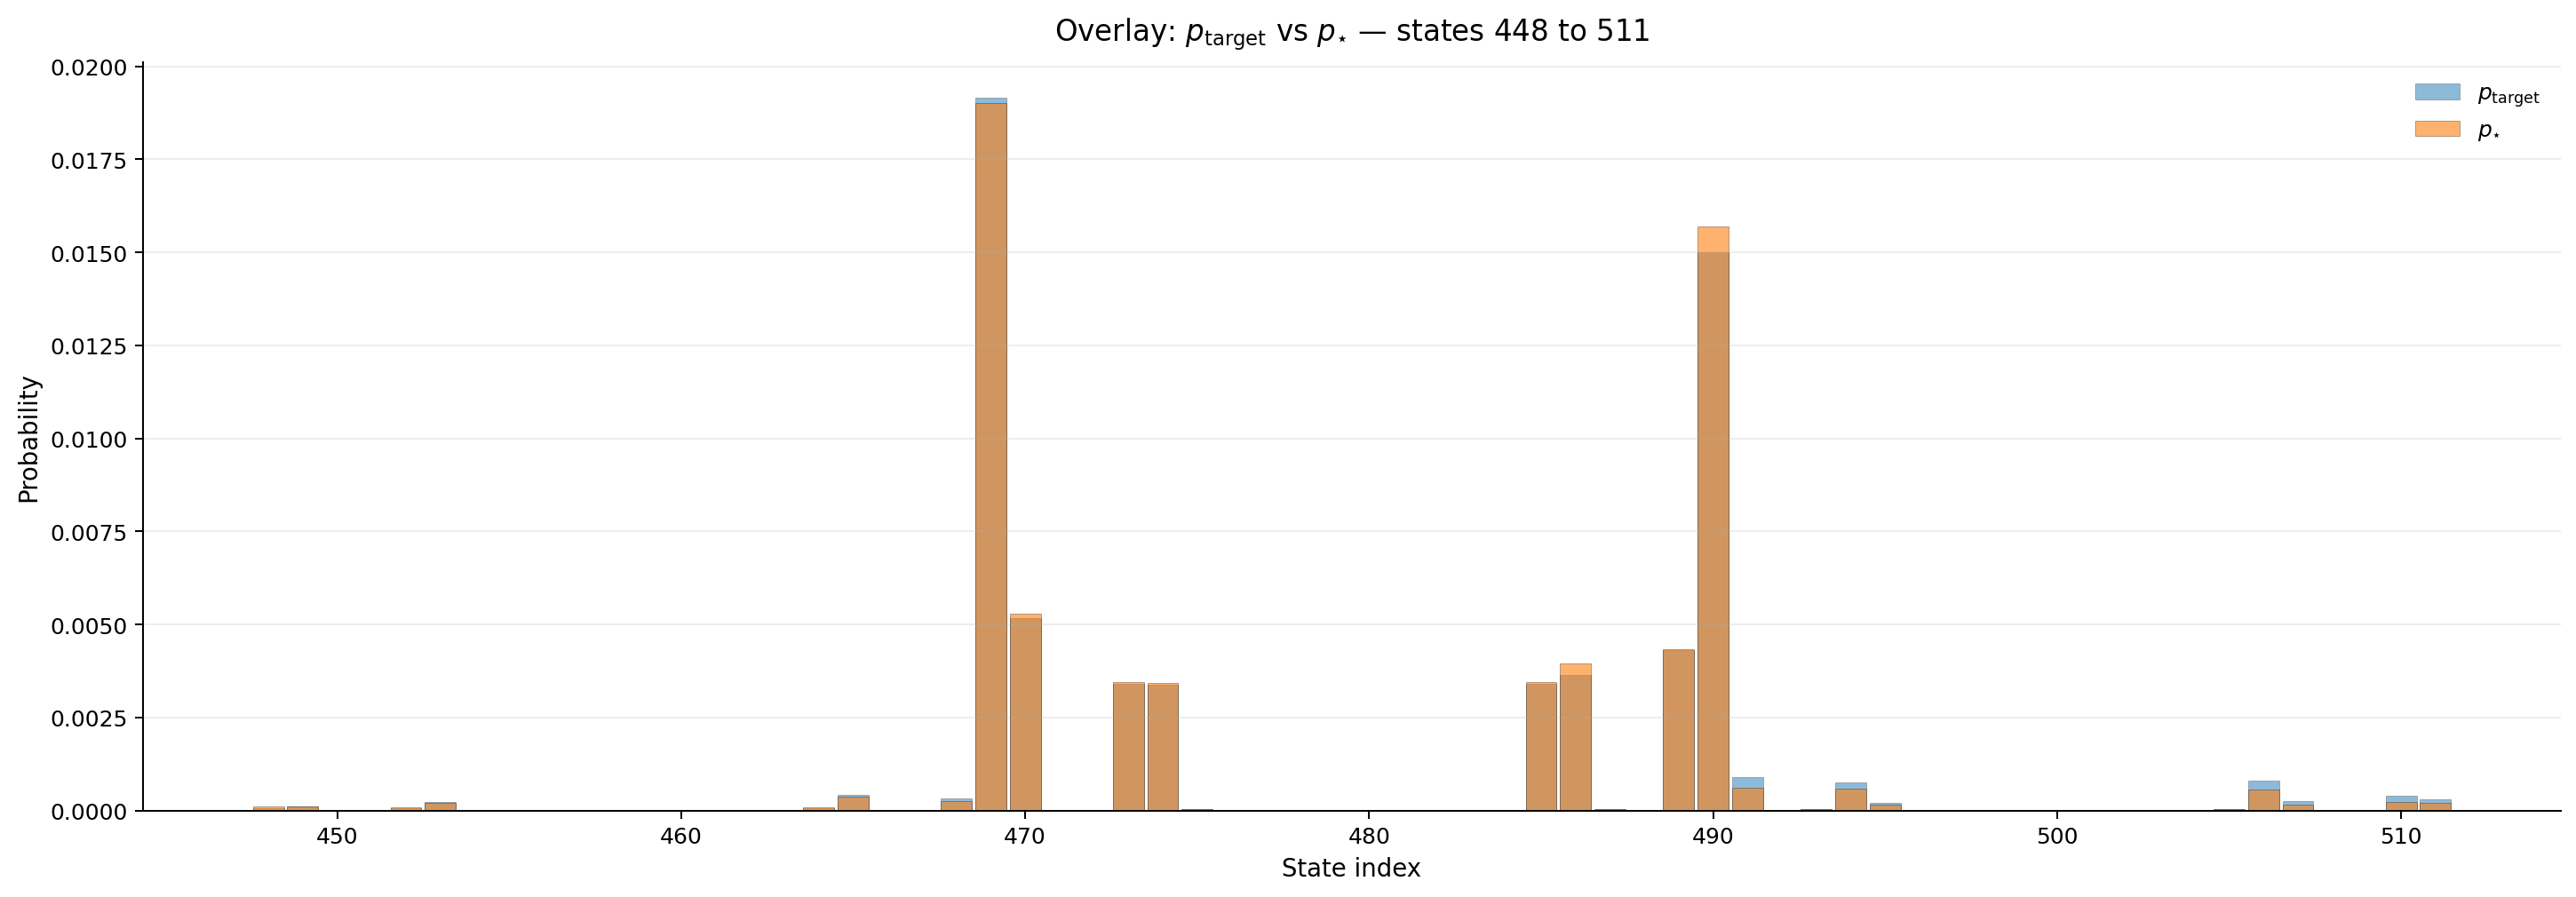

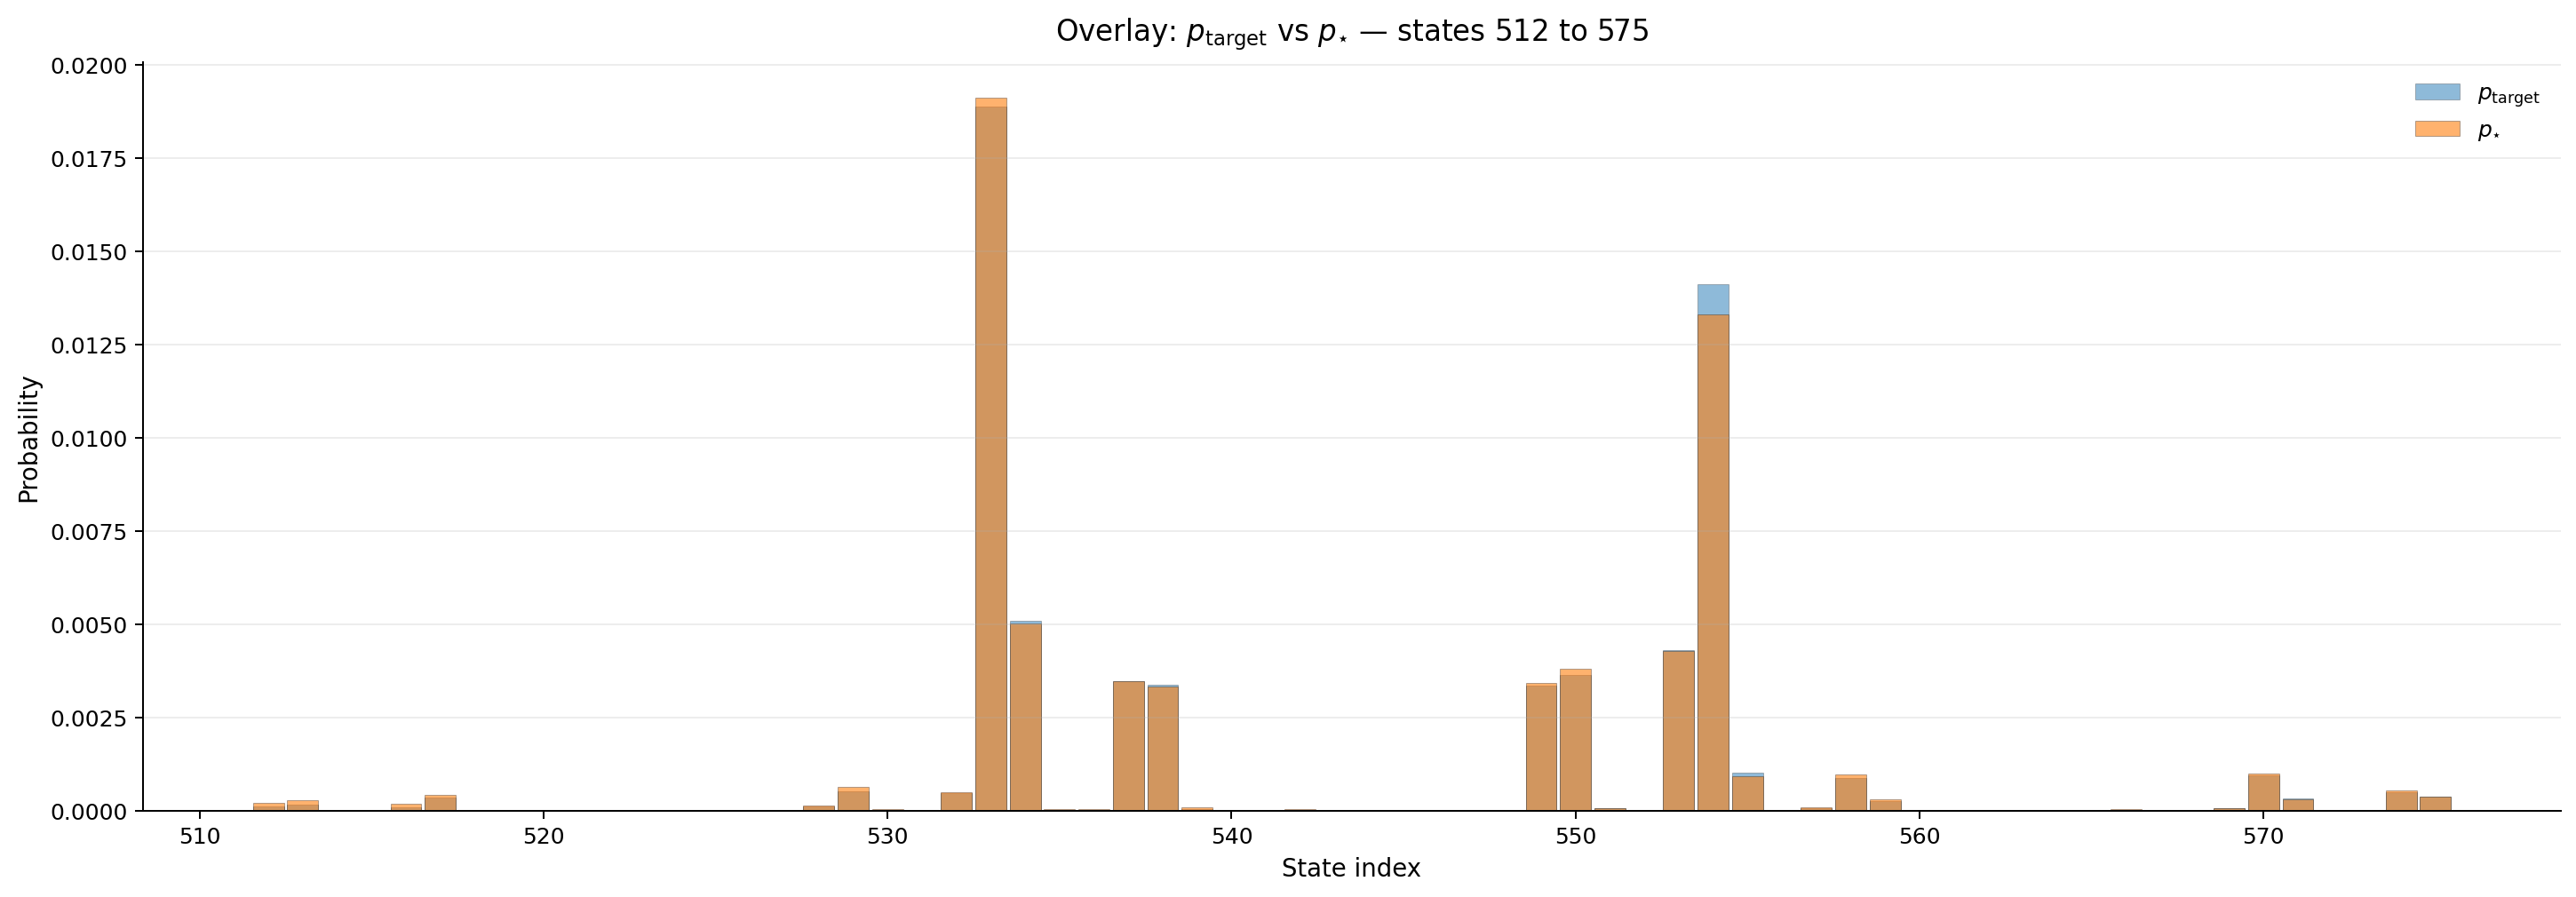

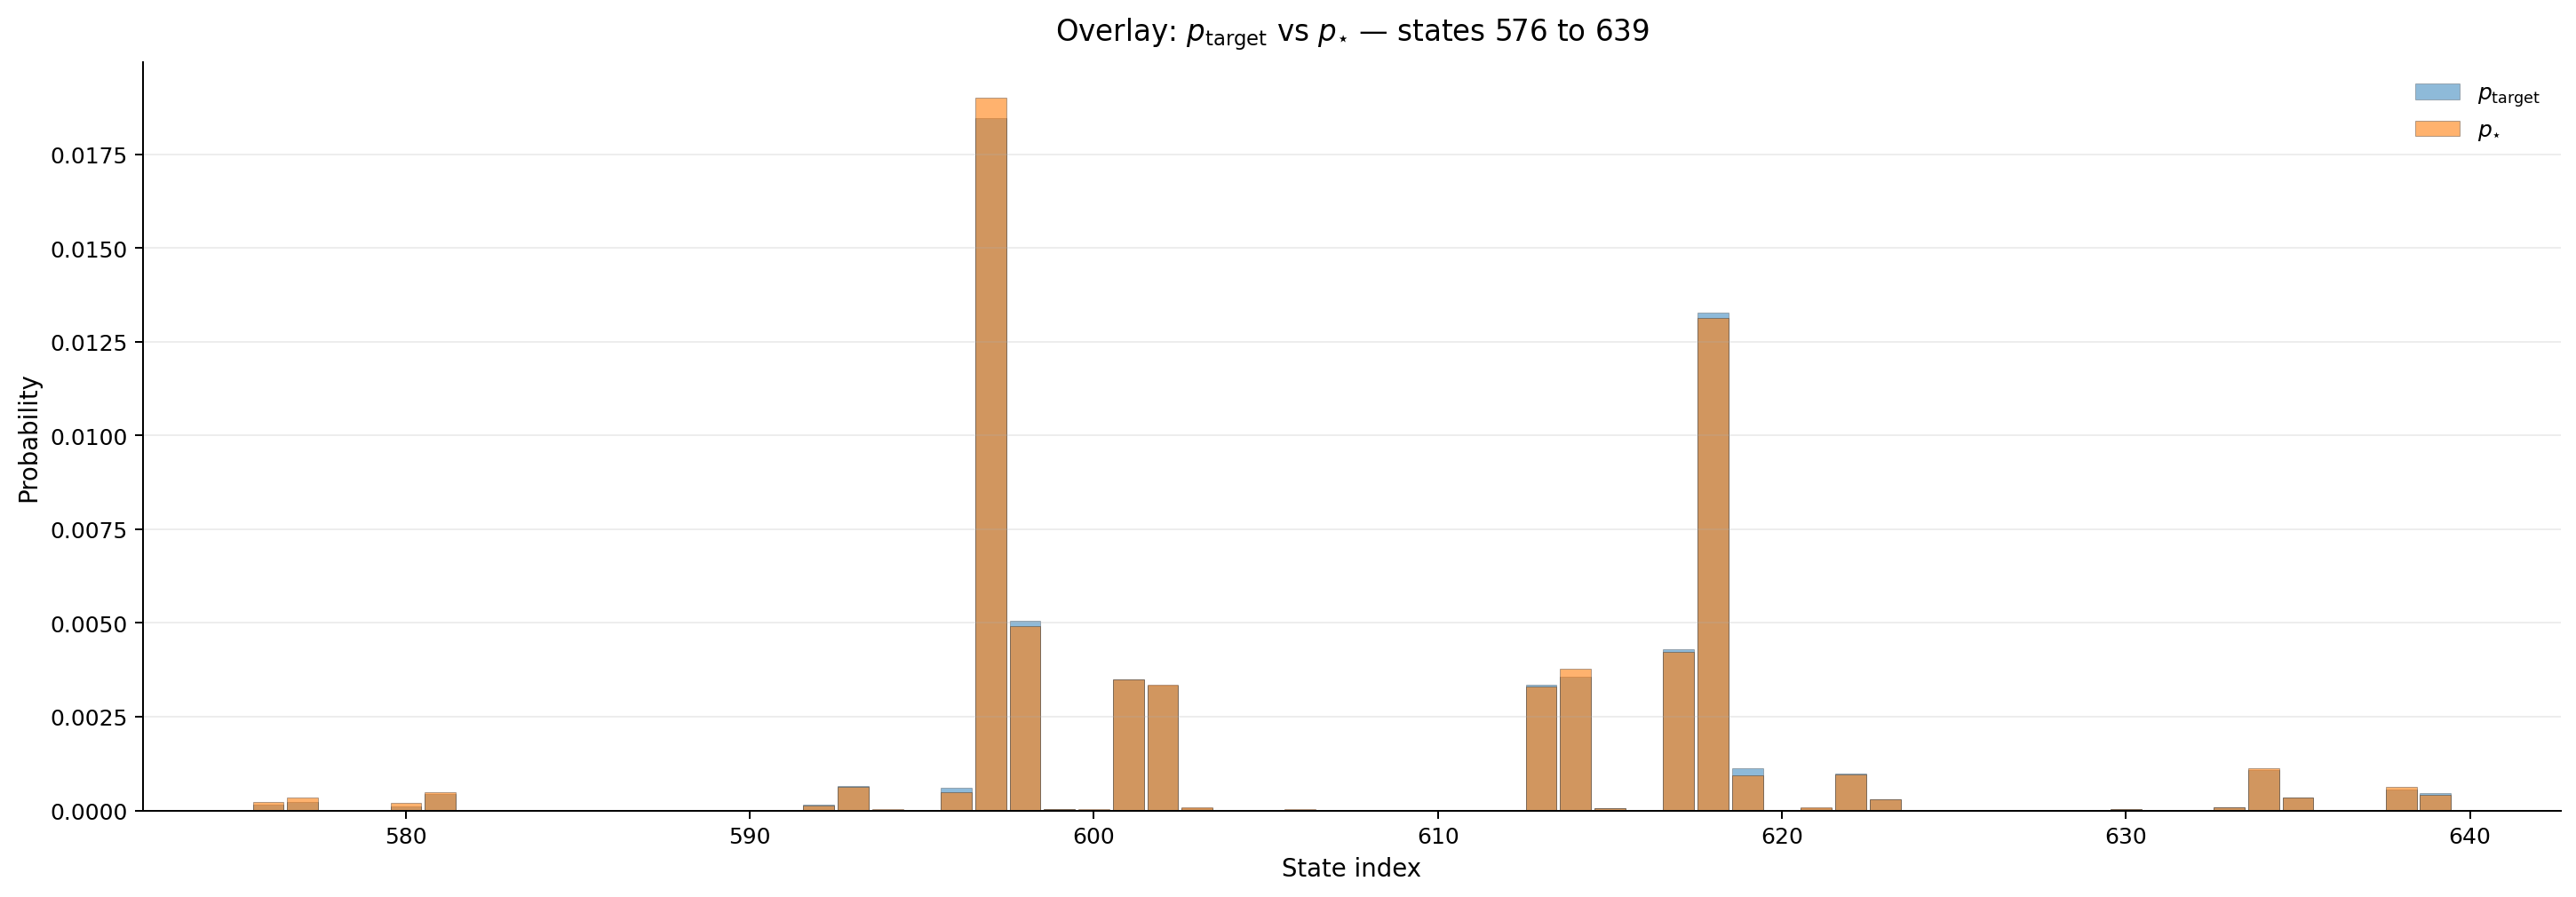

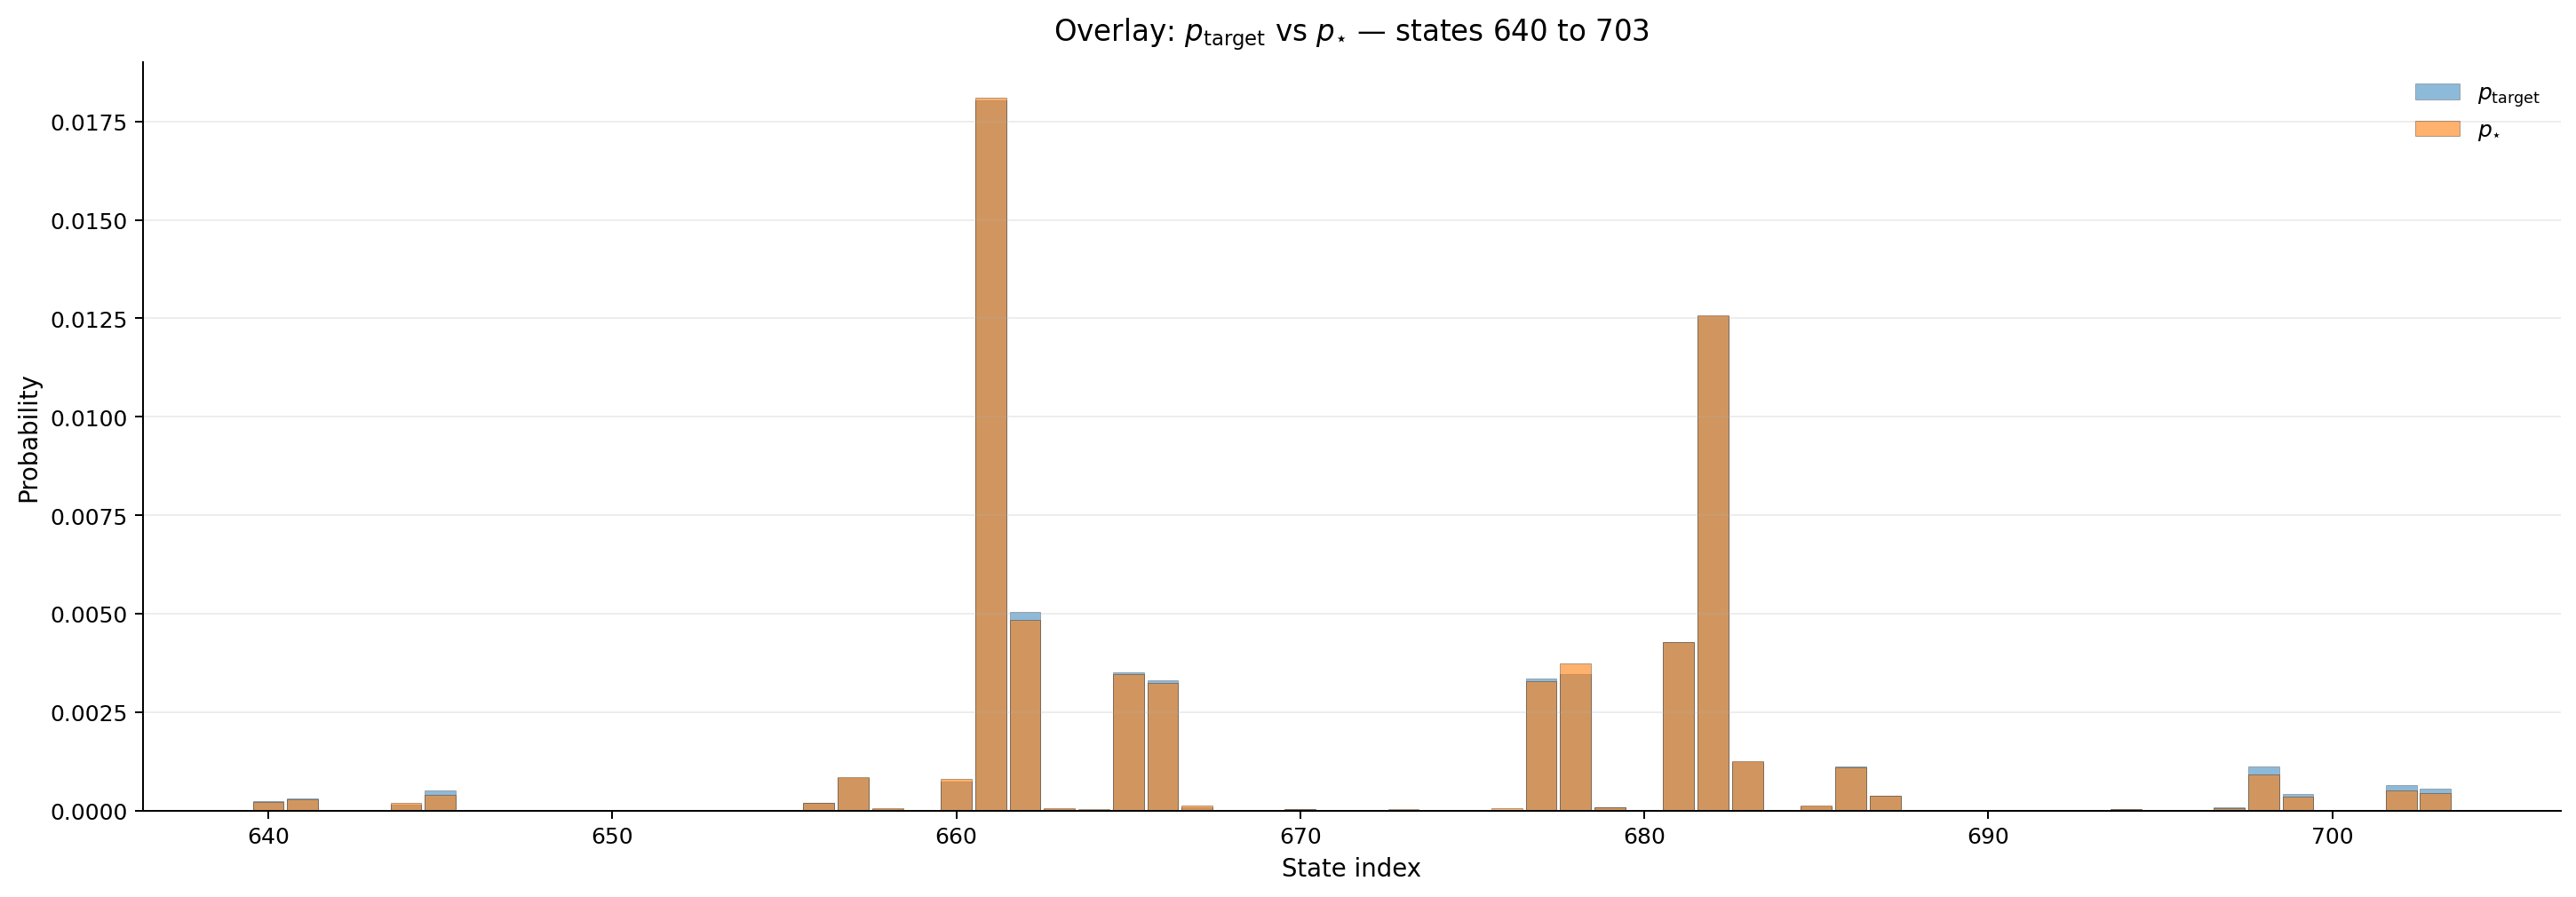

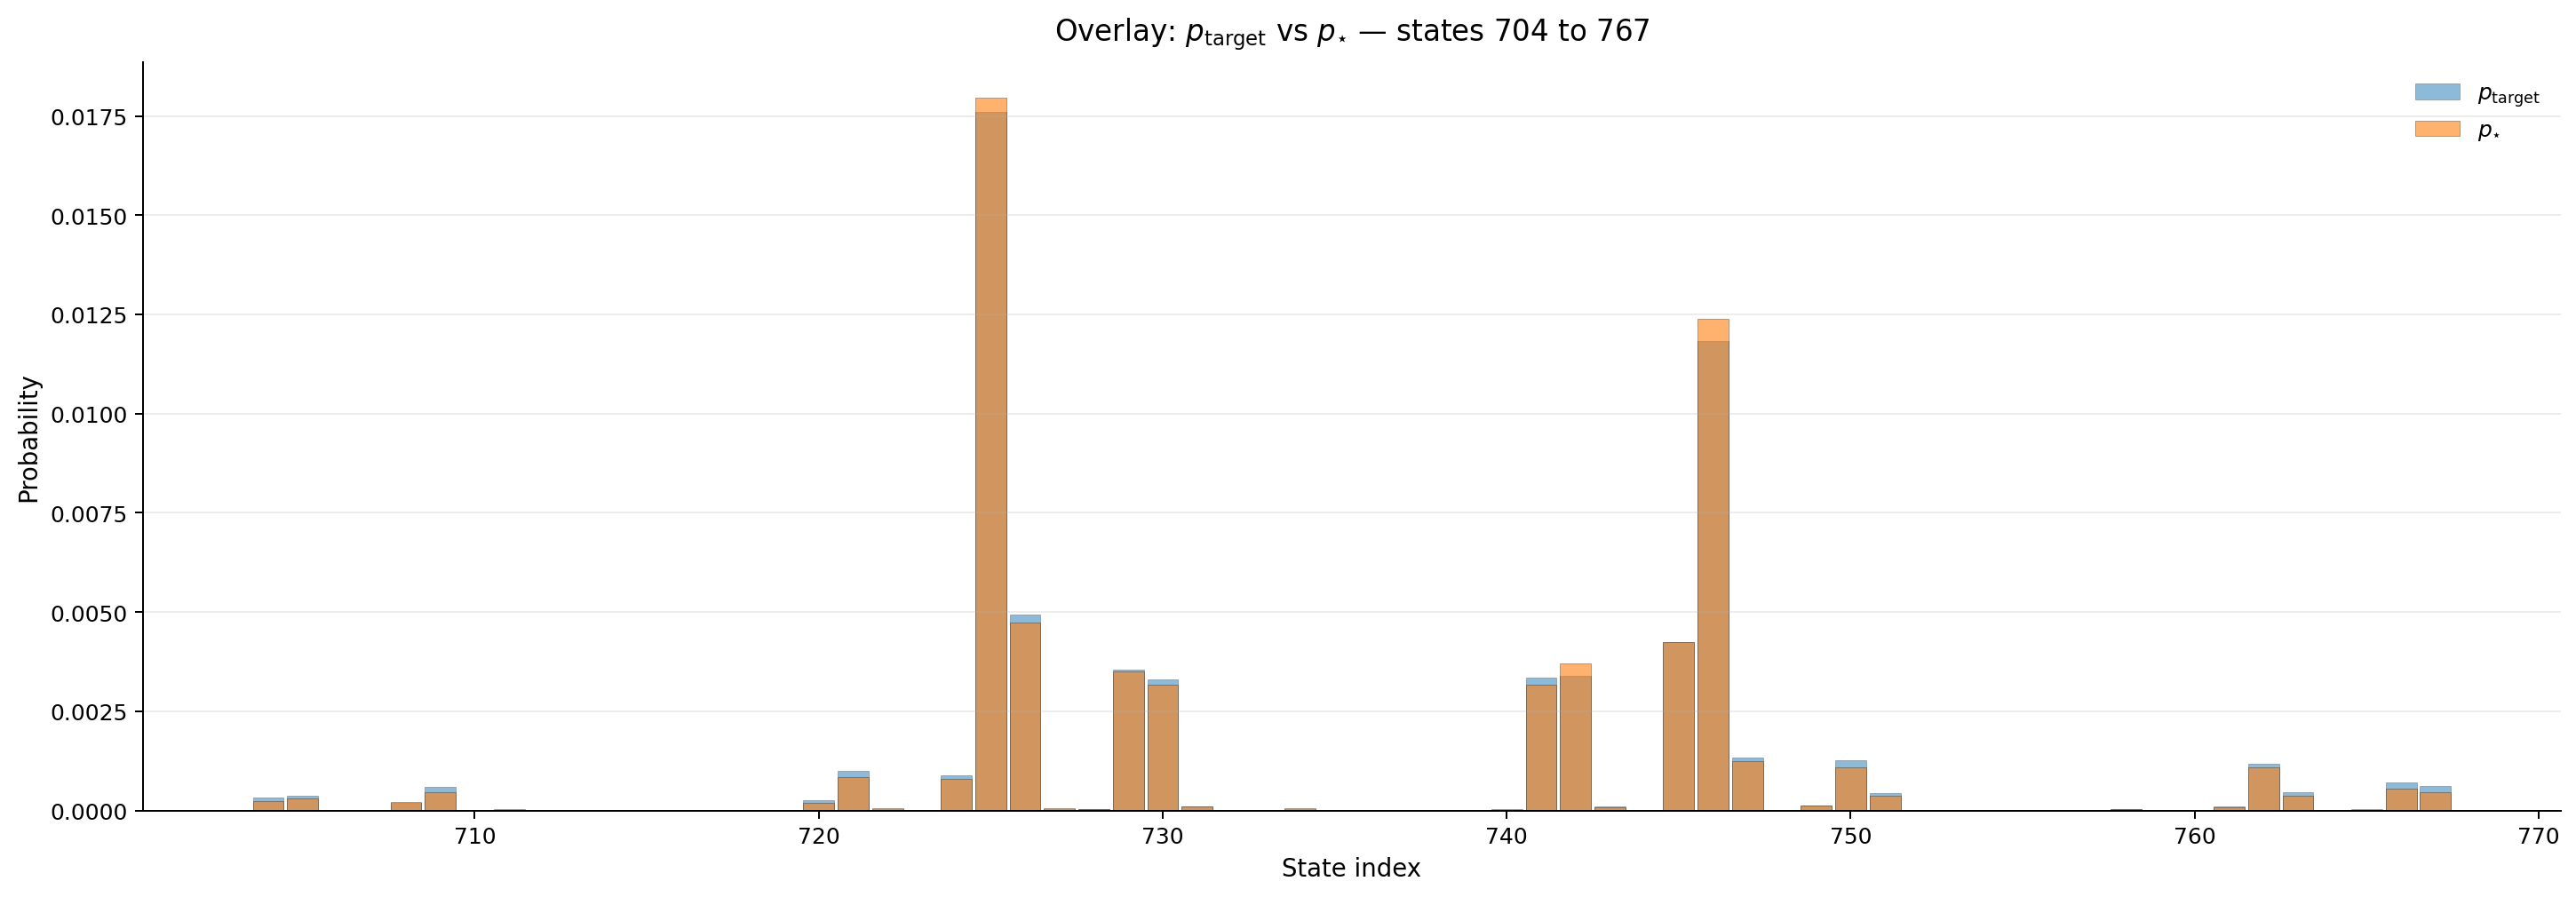

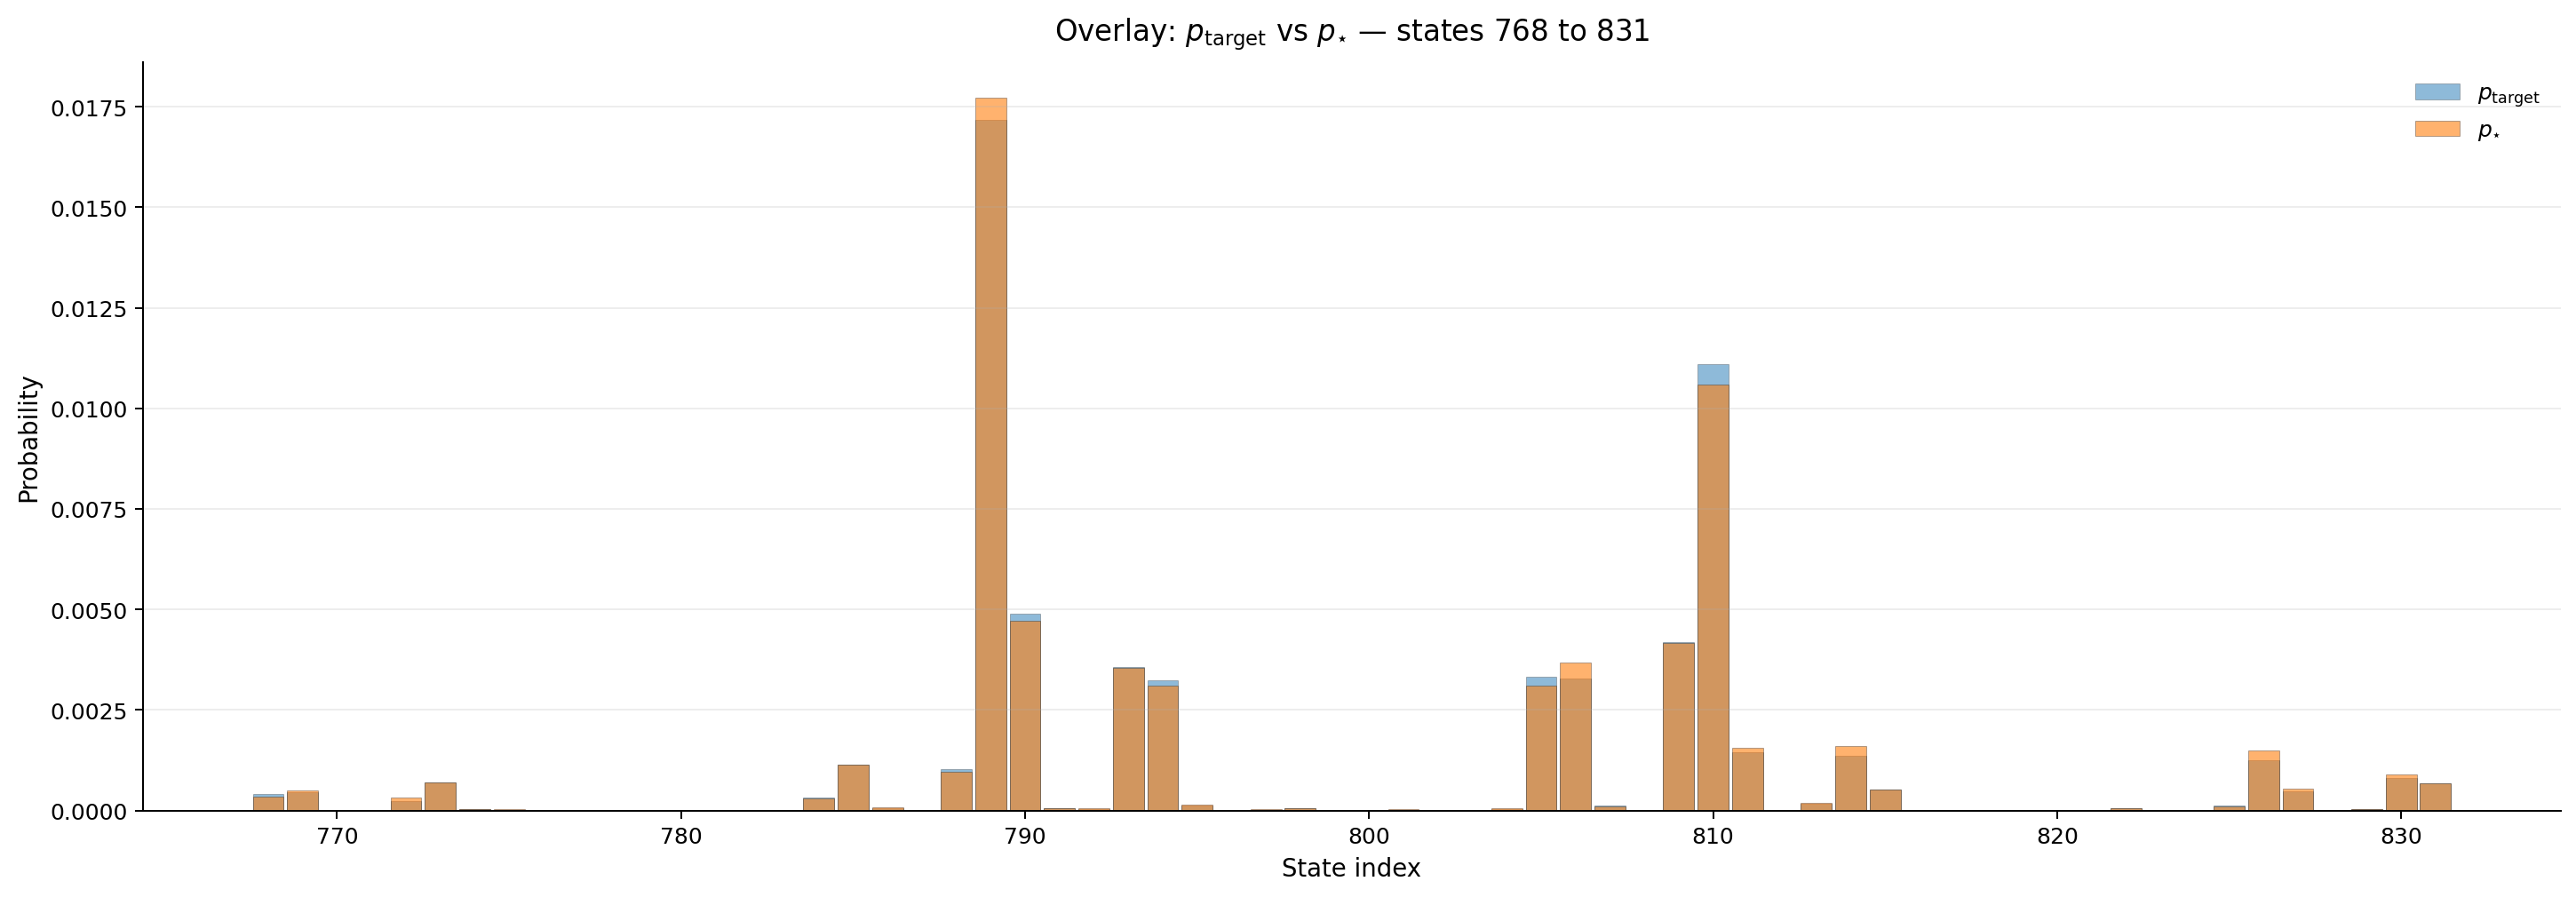

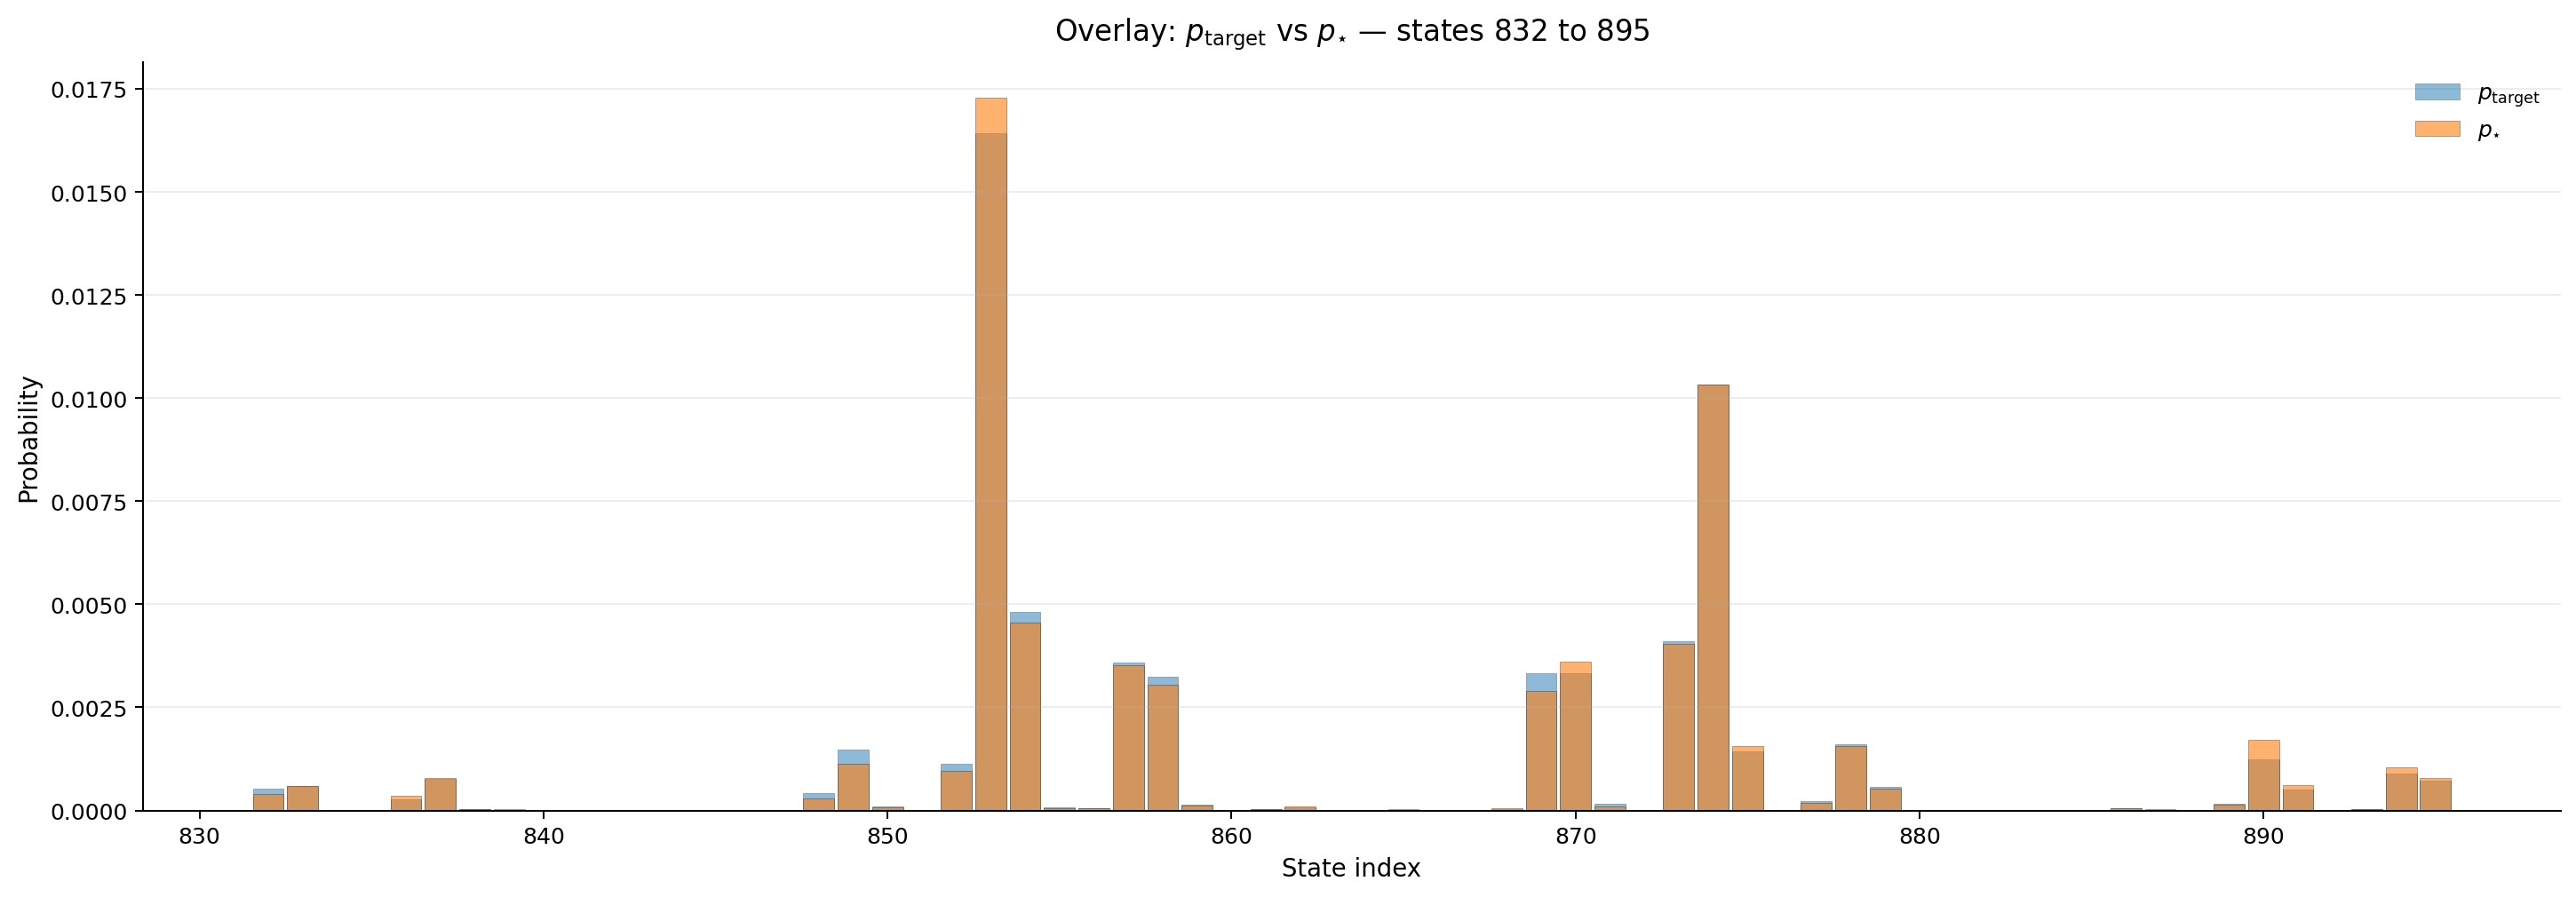

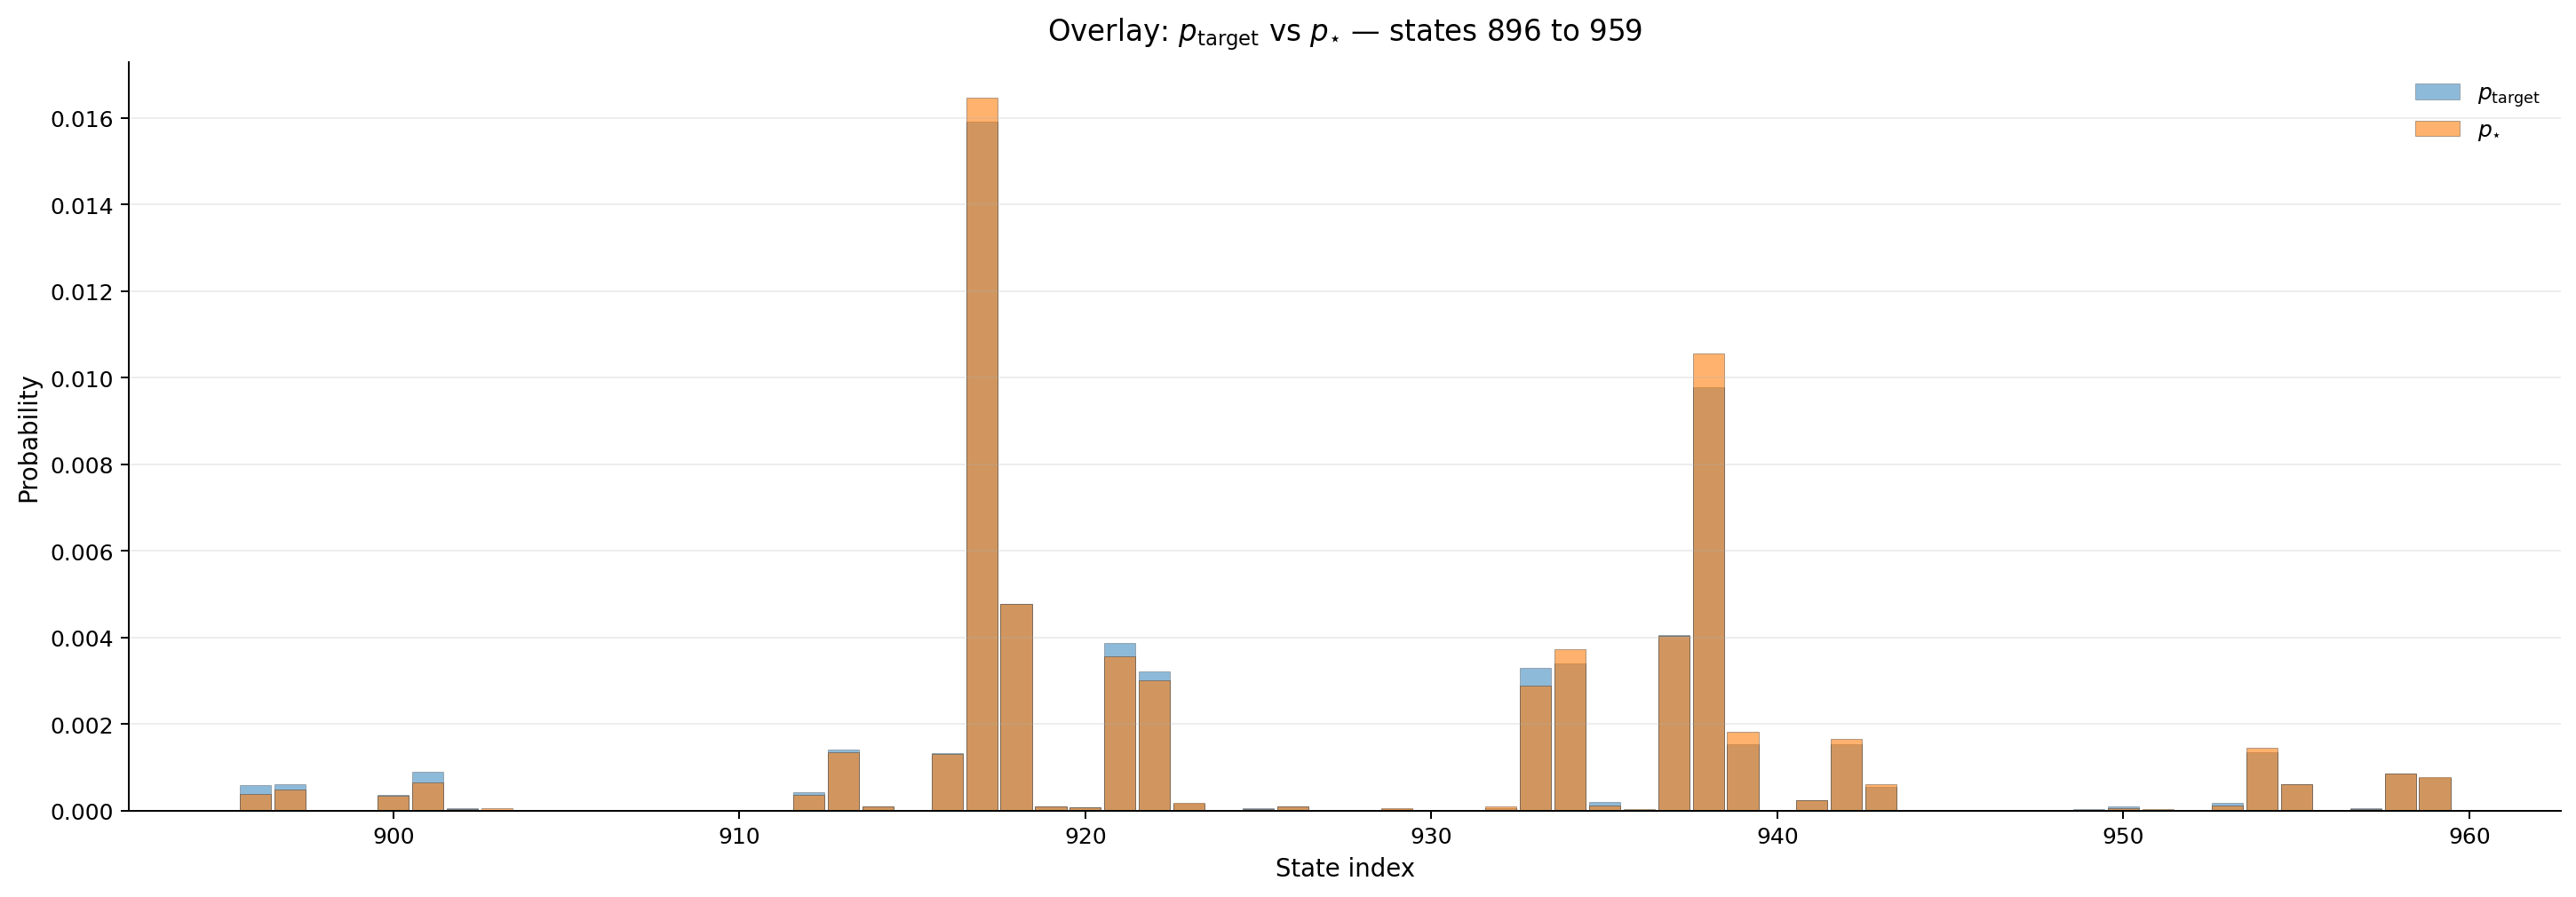

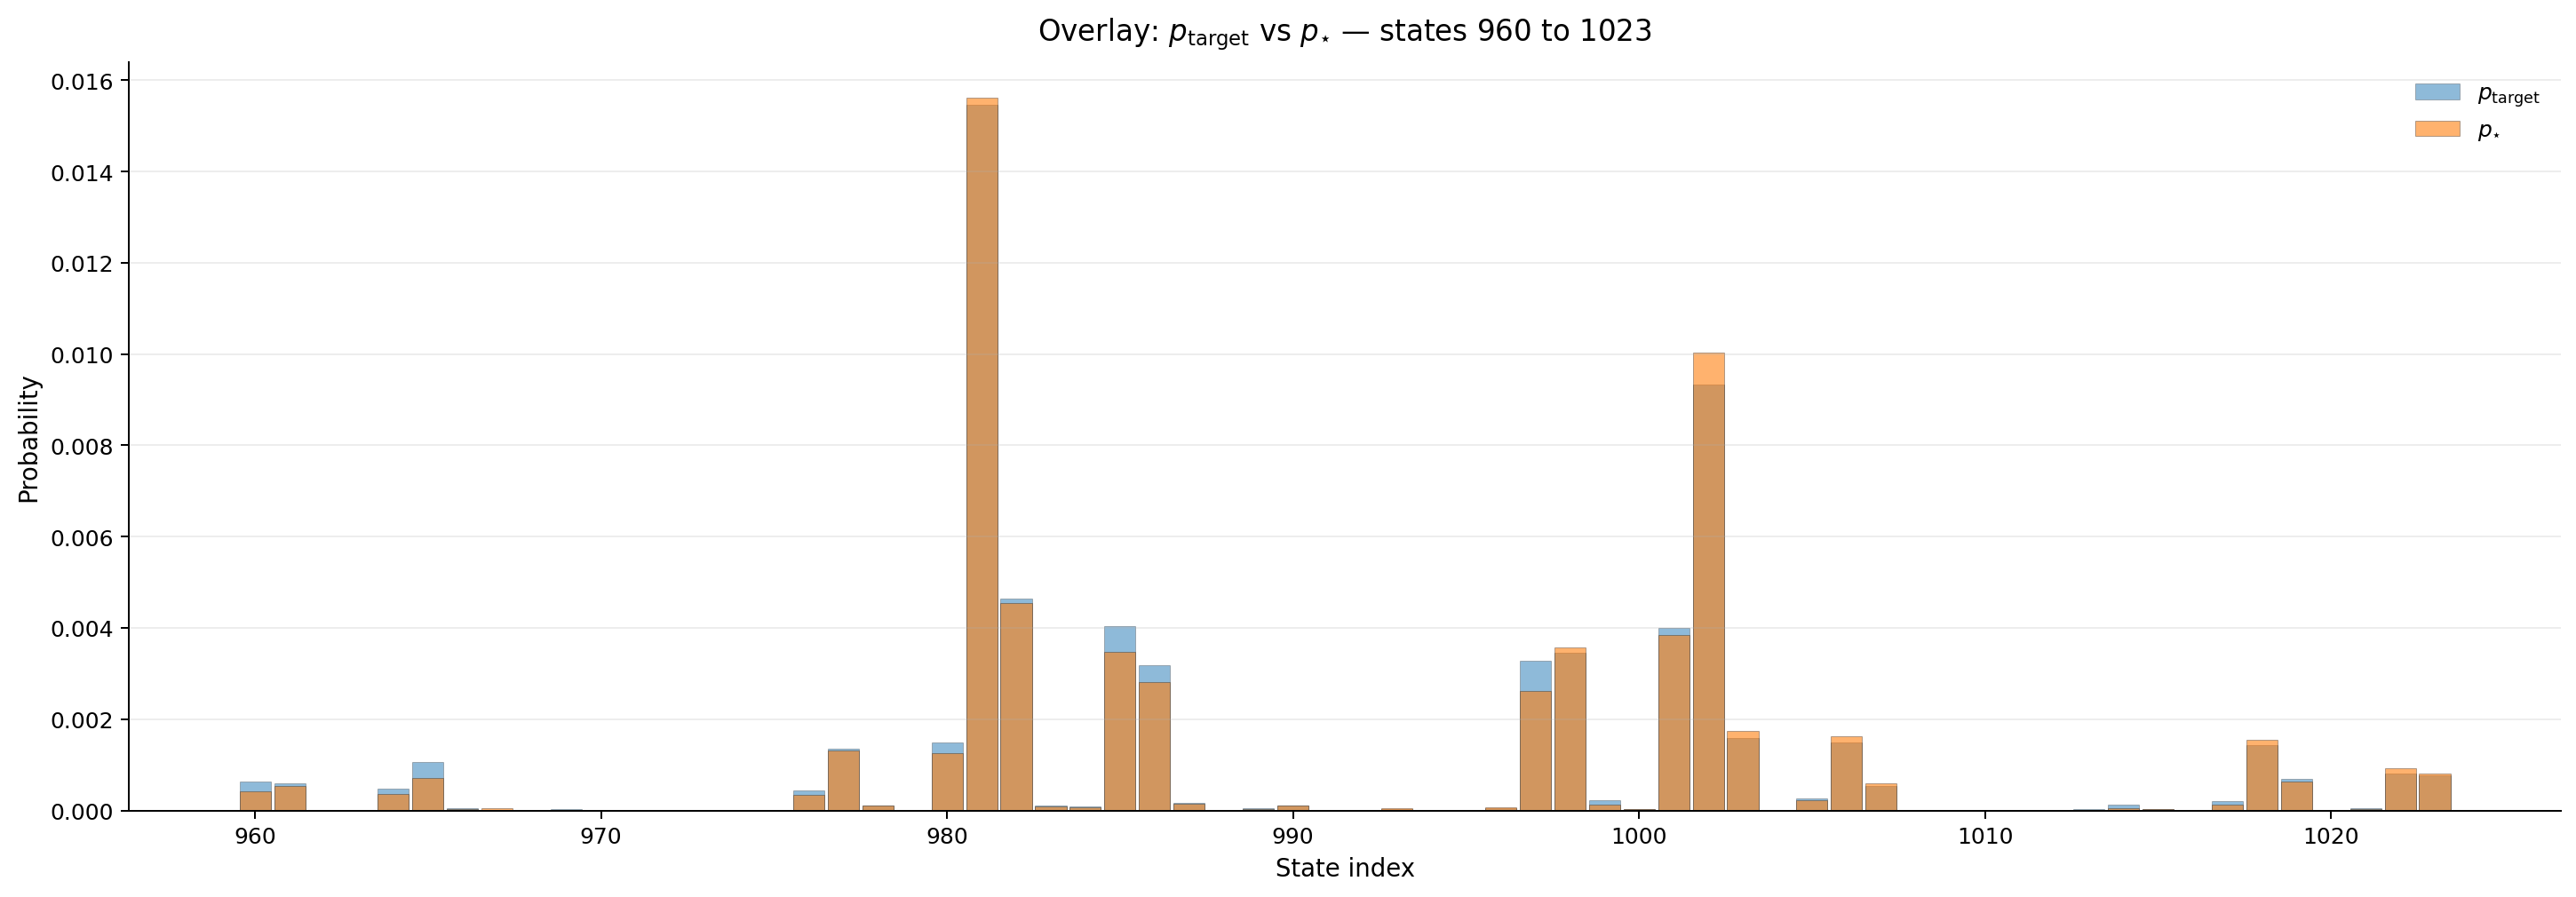

In [34]:
figs = comparative_plot_distributions(
    p_target=data["p_target"],
    p_star=data["p_star"],
    block_size=64,
    log_scale=False,
    alpha_target=0.50,
    alpha_star=0.60,
)